In [6]:
# 引入必要库
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib widget
# widget与本人环境冲突
%matplotlib inline

# 常微分方程求解

## 常微分方程的定义

常微分方程（Ordinary Differential Equation, ODE）是数学中的一类微分方程，描述了一个未知函数的导数与自变量之间的关系。具体来说，ODE是一个包含未知函数、它的导数和自变量的方程。

常微分方程通常具有以下形式：

$F(t, y, y', y'', \ldots, y^{(n)}) = 0$

其中：

- $y$ 是待求解的未知函数。
- $t$ 是自变量，在物理问题中常为时间。
- $y'$、$y''$、$\ldots$、$y^{(n)}$ 表示未知函数 $y$ 对$t$不同阶导数。
- $F$ 是一个函数，将自变量 $t$、未知函数 $y$ 和其各阶导数作为参数。

ODE的目标是找到一个函数 $y(t)$，使得方程 $F(t, y, y', y'', \ldots, y^{(n)}) = 0$ 成立。

ODE根据它们的阶数（导数的最高阶数）和形式可以分为不同类型，包括一阶ODE、二阶ODE等。解常微分方程的目标是找到满足初始条件的解（例如，$y(t_0) = y_0$ 和 $y'(t_0) = y'_0$）。


## 常微分方程求解的基本思路

一阶常微分方程可表示为$y'(t) = f(y,t)$的形式，数值求解不能直接获得$y(t)$的表达式，而是计算出一系列时间点$t_1, t_2, ...,t_n$处的值$y(t_1),y(t_2),...,y(t_n)$。数值求解的基本思路为：
1. 给定初始条件$y(t_0)$,相邻时间点$t_1$的解可用积分表示：
$y(t_1) = y(t_0) + \int_{t_0}^{t_1} {y'(t) d t}$
2. 积分得到$y(t_1)$后，继续迭代公式$y(t_{n+1}) = y(t_n) + \int_{t_n}^{t_{n+1}} {y'(t) d t}$，计算出$y(t_2),...,y(t_n)$ 

常微分方程求解本质上是通过**数值积分**迭代实现

## 物理学中的常微分方程

常微分方程可以描述了一个物理、化学、生物等领域中的各种现象，例如弹簧振动、化学反应速率、生物种群动态等。
在物理学中，常微分方程常用于描述单点或N体的运动规律，几个经典的常微分方程应用有: 天体在万有引力下的运动，带电粒子在静电场或静磁场中的运动，弹簧振动，以及物体在介质中的阻尼运动等。这些物理问题的特征为可以将运动对象简化为单点或N体，其速度与加速度变化可以写为位置的一阶与二阶导，因此是一个二阶常微分方程问题。

例如，对于弹簧的阻尼运动来说，它受到阻尼力，弹簧自身刚度与外力共同作用，对应的常微分方程为：

$ m \frac{{d^2 \mathbf{r}}}{{dt^2}} + C \frac{{d \mathbf{r}}}{{dt}} + k \mathbf{r} = \mathbf{F}(t)$

其中：

- $t$ 是自变量
- $r(t)$ 是物体的位移（作为时间$t$的函数），也是待求函数。
- $m$ 是物体的质量。
- $C$ 是阻尼系数，描述了阻尼力的强度。
- $k$ 是弹簧常数，描述了弹簧的刚度。
- $F(t)$ 是外力作用在物体上的函数。

注意到这里$r$可以是三维矢量，因此这是一个二阶常微分方程组。

## 数值求解常微分方程的基本步骤

数值求解ODE的方法是近似求解出一系列离散的$t_i$点对应的$y(t_i)$。这通常包括以下步骤：

1. **建立常微分方程模型**：首先，需要根据具体的物理问题建立微分方程模型。例如，如果想知道某个物体的运动规律，需要通过该物体的受力情况，确定运动方程，并给出$y' = f(t, y)$的形式，其中$y(t)$为描述物理运动规律的函数，如位置函数或速度函数，$t$是自变量。

2. **设定初始条件与参数**：将自变量$t$的区间划分成小步骤$t_1, t_2, ...,t_n$，即将连续问题转化为离散问题。

3. **使用数值方法求解**：从初始条件$y(0)$开始，使用数值解法迭代地计算$y(t_1),y(t_2),...,y(t_n)$的值。

4. **分析误差**：数值方法都会存在误差，为确保计算结果可靠，需分析计算误差，是否满足解决问题所需要的精度要求。

Python中有许多库和工具可以用于求解常微分方程，其中最常见的是SciPy库中的`odeint`函数。这个函数可以用于求解一阶或高阶常微分方程，以及常微分方程组。

## odeint 实例 1：求解一阶一维常微分方程

我们先不考虑具体的算法，而演示如何使用`scipy.intergrate.odeint`来求解最基本的一阶一维常微分方程。

这个例子尝试求解给定初始条件下，一个受恒定推力和阻尼力（如空气阻尼）物体的运动速度随时间的变化规律。以下为基本步骤：

### 建立微分方程模型

物体的运动速度$v(t)$满足的常微分方程可以写为：

$ m \frac{d \mathbf{v}}{dt} = f - k v^2 $ 

其中：
- $m$: 物体质量
- $v$: 待求速度函数
- $f$: 推力
- $k v^2$: 阻尼力，阻尼力有多种形式，这里使用的是对速度平方依赖的阻尼力，如空气阻尼
- $k$: 阻尼系数，该值通常是根据物体形状以及所在环境等因素测定的实验值

使用`scipy.intergrate.odeint`来求解这个方程，需要通过将微分方程模型写为$y'(t) = F(y,t,...)$的形式，其中$y$为待求解函数，并定义一个函数返回$y'(t)$的值:

```
def dydt(y, t, ...):
   # 实现具体表达式： dydt = F(y, t, ...)
   return dydt
```
其中，在求解中依赖的其他参数需放在y,t后。

以下基于我们要解决的常微分方程,定义函数dvdt,返回速度导数，即加速度：

In [3]:
def dvdt(v, t, f, m, k):
    return (f - k*v**2)/m

注意：虽然dvdt函数并不依赖时间t，但参数表中不能省略t。

### 确定初始条件与参数
常微分方程需要确定初始条件和所有常数参数才能进行求解。我们忽略单位，假定初始速度$v_0=0$，质量$m=1$，$k=0.1$，推力为恒定值$f = 1$。

In [4]:
v0 = 0
m = 1
k = 0.1
f = 1

### 使用Scipy的odeint实现数值求解

`scipy.intergrate.odeint`为常微分方程的求解函数，有三个主要参数需要输入：

- func：常微分方程函数，用于计算$y'(t)=F(y,t,...)$，有两个固定参数：待求函数值或向量 `y` 和自变量 `t`。
- y0：函数的初始值。
- t：待求解自变量$t_1, t_2,...t_n$组成的数组
- args(可选关键词参数): 如果func包含除了y,t之外的参数，由args传入。

odeint将更具这些参数，求解$t$数组中的点$t_1, t_2,...t_n$对应的$y$值$y(t_1),y(t_2),...,y(t_n)$，并以**二维数组**形式返回结果。
注意，odeint可以求解常微分方程组，为统一返回形式，即使y是标量，返回的y数组也是二维的，形状为(n, 1)，其中n表示t数组的大小。

我们在上面步骤中已实现了func对应的dvdt，并定义了y0对应的v0，现在只需再决定待求解的时间点数组t对应的t_arr，就能带入odeint进行求解

In [1]:
# 待求解的时间点数组，用NumPy的linspace生成0-200等间距的时间点100个
import numpy as np
t_arr = np.linspace(0,20,100)

In [7]:
# 带入odeint，注意f, m, k这些常数参数通过args传入：
from scipy.integrate import odeint
v_arr = odeint(dvdt, v0, t_arr, args=(f, m, k))
# 求解结果存入到v_arr中，是与t_arr对应的等大小数组

可见，使用`odeint`解方程步骤并不复杂，只需要一行代码，我们将求解结果画图分析：

Text(0, 0.5, 'v')

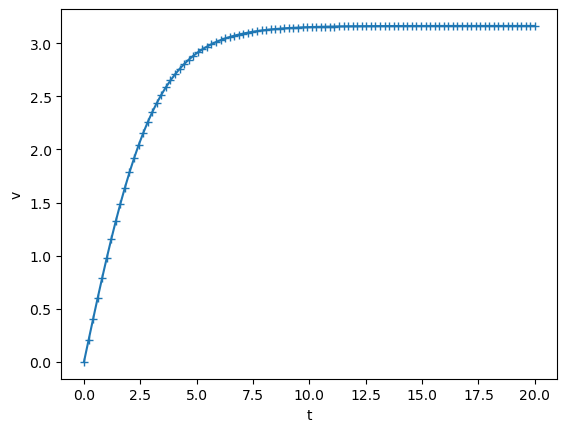

In [6]:
# 将结果画图
import matplotlib.pyplot as plt
fig = plt.figure()
plt.plot(t_arr, v_arr, '-+')
plt.xlabel('t')
plt.ylabel('v')

In [22]:
#注意v_arr是一个二维数组，形状为(100,1)
print(v_arr.shape)

(100, 1)


## odeint 实例2：求解一阶二维常微分方程

上诉例子是一个一维一阶的简单常微分方程，接下来我们以另一个例子来讲解一阶二维常微分方程的求解。这个例子考虑一个简单的飞机飞行模型：在空中飞机受到三个力的影响，最终分解为两个方向：

- 飞行水平方向：飞机发动机推力$f$，与机翼受空气压力在水平方向的分量（阻力）
- 垂直方向：重力$mg$与 与机翼受空气压力在垂直方向的分量（升力）

空气压力的形式和空气阻尼类似，可以简单表征为 $\frac{1}{2} C \rho S v^2$，受机翼仰角影响，会分配给阻力和升力，我们将分配角$\theta$作为参数。另外在飞行方向，飞机机身也有空气阻尼，但相比机翼给与的力较弱，我们这里忽略。

将两个方向的运动写为常微分方程组，其形式为：

- $ m \frac{d v_x}{d t} = f - k \sin(\theta) \left|\bf{v}\right|^2$
- $ m \frac{d v_y}{d t} = k \cos(\theta) \left|\bf{v}\right|^2  - mg$ 

其中 $k = \frac{1}{2} C \rho S$

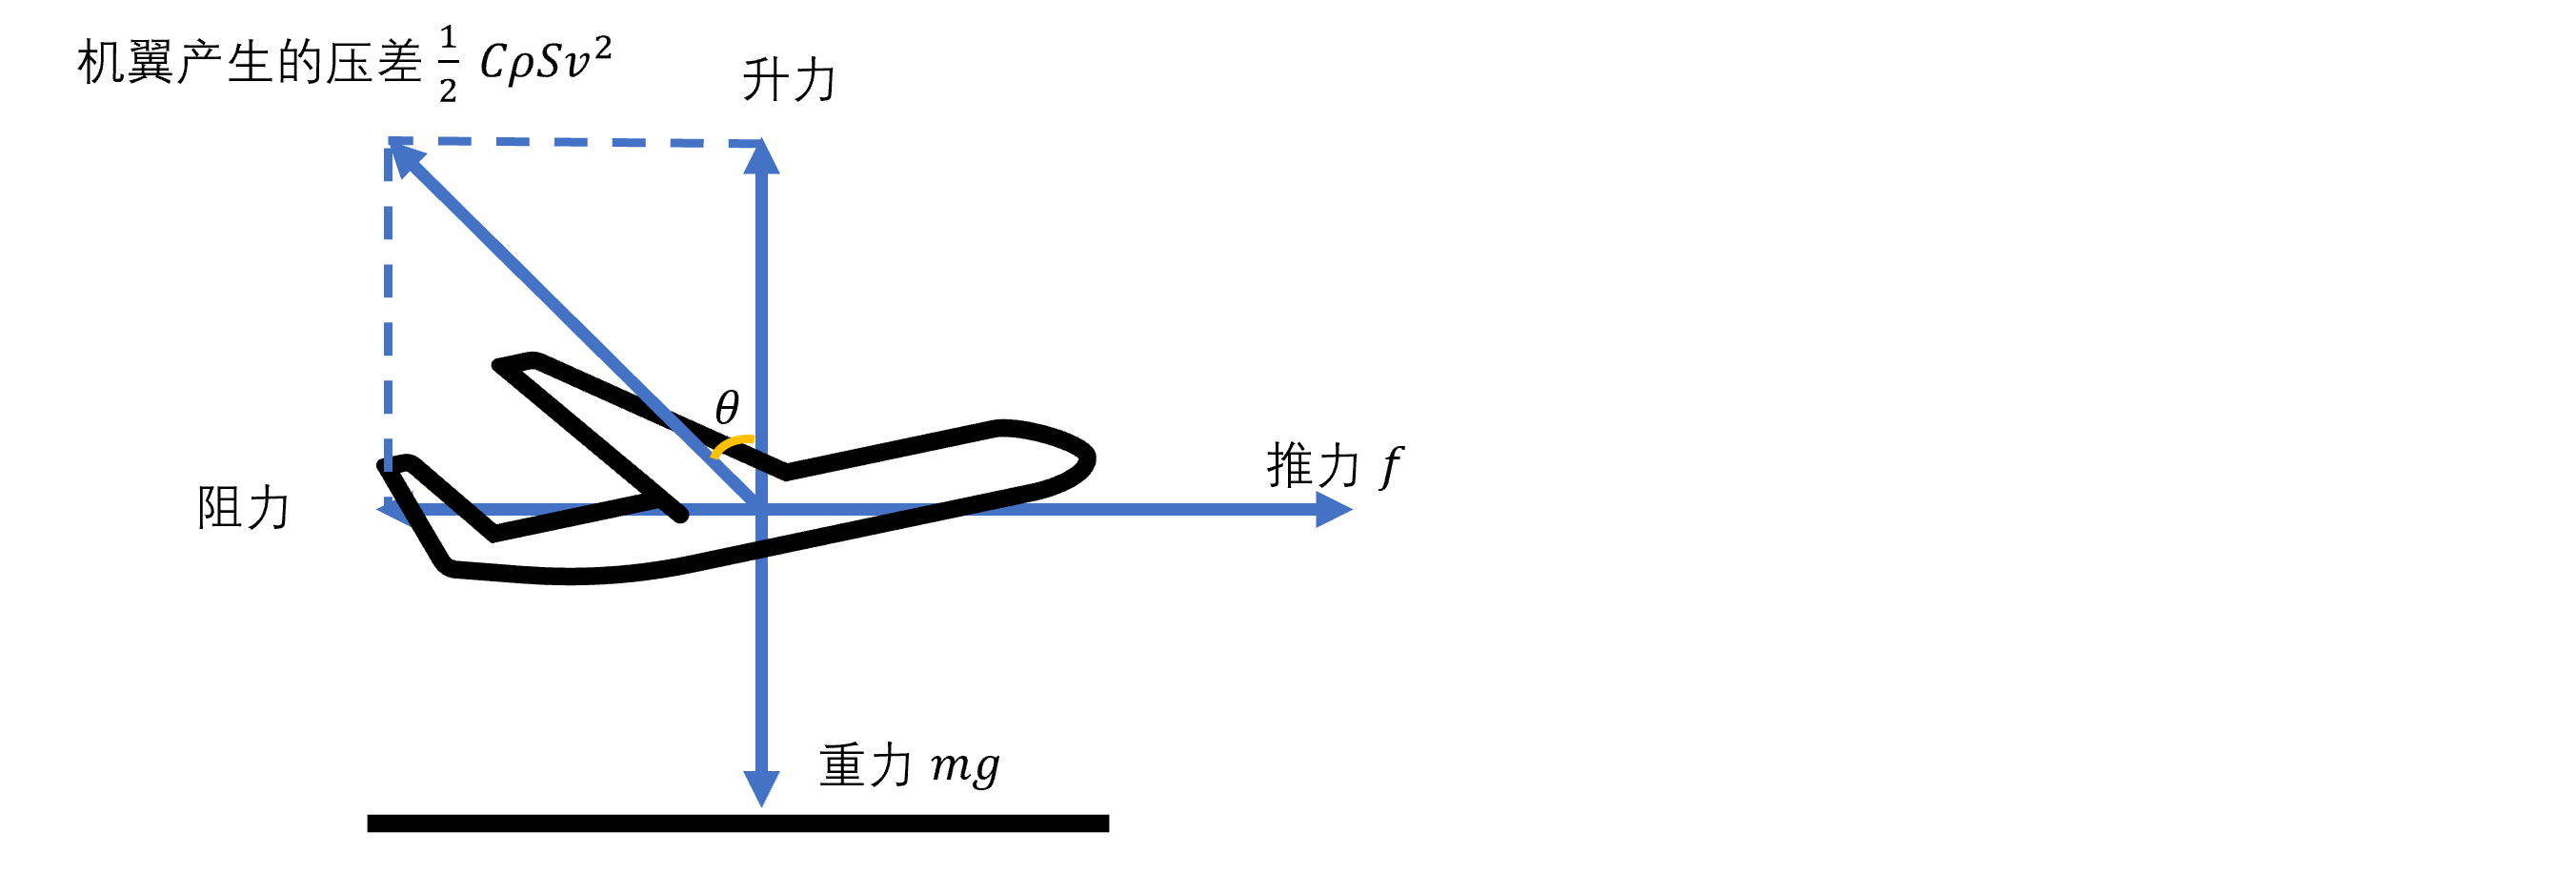

对于二维形式的常微分方程组，使用`odeint`的基本形式与一维形式没有区别，只是在定义`func`和`y0`时需注意将标量替换为两元素的数组或列表，以下具体介绍：

常微分方程的待求函数`y`是速度$v$，是一个二维向量： `v=(vx, vy)`，对应的导函数也是二维向量：`(ax, ay)`。这种情况下，对`func`函数对应的`dvdt`函数，传入的`v`参数是一个两元素的数组或列表，包含`vx`和`vy`，返回的也是一个两元素的数组或列表，包含`ax`和`ay`。另外，其他需要传入的参数有：质量`m`，重力加速度`g`，推力`f`，空气压力参数`k`，倾角`theta`：

In [9]:
def dvdt(v, t, m, g, f, k, theta):
    # 提取vx和vy
    vx, vy = v
    
    # 首先计算速度的平方 vx^2+vy^2
    v2 = vx**2 + vy**2
    
    # 空气压差产生的力
    fd = k*v2
    
    # 水平方向加速度
    ax = (f - fd*np.sin(theta))/m
    
    # 垂直方向加速度
    ay = fd*np.cos(theta)/m - g

    # 返回两个方向的加速度
    return [ax, ay]

我们设置初始条件和其他参数，注意初始条件也不再是标量，而是两元素的列表

In [10]:
# 参数初始化

# 初始速度，注意需要初始两个方向的速度
v0 = [200, 0] #m/s

# 其他参数

# 阻尼系数
C = 0.4
rho = 1.293 # kg/m^3
S = 100 # m^2 
k = 0.5*C*rho*S

# 倾角
theta = np.pi/2 * 0.1

# 推力
F = 150000 # N

# 飞机质量
m = 100000 #kg

# 重力加速度
g = 9.8 #m/s^2

定义时间点数组

In [11]:
# 时间数组
t_arr = np.linspace(0,100,100)

带入`odeint`求解

In [12]:
from scipy.integrate import odeint
v_arr = odeint(dvdt, v0, t_arr, args=(m, g, F, k, theta))

ms_to_kmh = 3.6 # m/s -> km/h
v_arr *= ms_to_kmh # 单位转换

注意因为求解的是二维，因此v_arr的数组形状为(100,2)，第一个维度表示时间点序列，第二个维度表示速度两个分量vx, vy

画出两个速度的轨迹图，可看到横向速度在逐渐下降，纵向速度先上升后下降。这里的速度对参数极为敏感，如果改变其中之一，如推力，倾角等，会发现速度增长过快，这时候机身的空气阻不可忽略，这个简单的模型不再适用。

Text(0, 0.5, '$v_y$[km/h]')

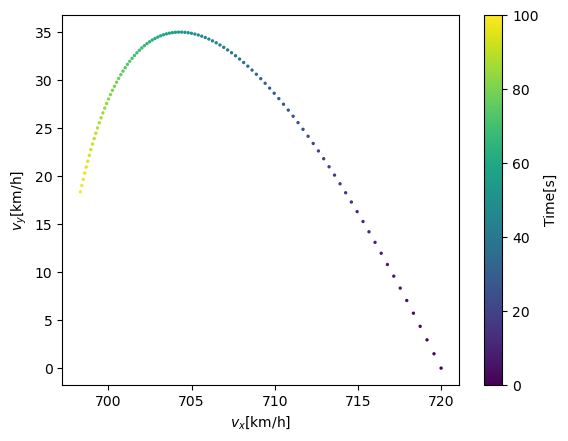

In [11]:
# 将结果画图
fig = plt.figure()
plt.scatter(v_arr[:,0], v_arr[:,1],s=2,c=t_arr)
cbar = plt.colorbar()
cbar.set_label('Time[s]')
plt.xlabel(r'$v_x$[km/h]')
plt.ylabel(r'$v_y$[km/h]')

## odeint 实例3：求解二阶二维常微分方程

上面飞机的ODE例子中，我们求解的是速度随时间的变化$v_x(t),v_y(t)$。如果需要求解的是位置随时间变化$x(t),y(t)$，则需解决的ODE成为二阶常微分方程组：

- $ m \frac{{d^2 x}}{{dt^2}} = f - k \sin(\theta) \left|\frac{{d \mathbf{r}}}{{dt}}\right|^2$
- $ m \frac{{d^2 y}}{{dt^2}} = k \cos(\theta) \left|\frac{{d \mathbf{r}}}{{dt}}\right|^2  - mg$

我们不能直接用`odeint`求解这样的二阶二维方程组，但是我们可以通过引入$\mathbf{r}(t)$的导数函数（速度） $\mathbf{v}(t)= d\mathbf{r}/dt$，将二阶常微分方程组转换为4个一阶常微分方程组：

- $ m \frac{d v_x}{d t} = f - k \sin(\theta) \left| \mathbf{v} \right|^2$
- $ \frac{d x}{d t} = v_x$
- $ m \frac{d v_y}{d t} = k \cos(\theta) \left|\mathbf{v}\right|^2  - mg$
- $ \frac{d y}{d t} = v_y$

其中，$|\mathbf{v}|^2 = v_x^2 + v_y^2$ 

可以看到，通过这样的转换，我们可以求解的函数可以重定义为一个四维矢量 `w = (x, y, vx, vy)`, 对应的导数为`dw/dt = (vx, vy, ax, ay)`，此时这个方程组可以表征为统一形式：$ \frac{dw}{dt} = F(w,t)$，其中`w = (x, y, vx, vy)`。

这样，我们就能像实例2那样，定义`func`，取名为`dwdt`，利用`odeint`同时求解出位置和速度。这种二阶转一阶的方法适用于所有高阶常微分方程

以下我们实现`dwdt`的函数：

In [12]:
def dwdt(w, t, m, g, f, k,theta):
    x, y, vx, vy = w # 提取速度和位置
    
    v2 = vx**2 + vy**2

    # 空气压差产生的力
    fd = k*v2
    
    # 水平方向加速度
    ax = (f - fd*np.sin(theta))/m
    
    # 垂直方向加速度
    ay = fd*np.cos(theta)/m - g
    
    return [vx, vy, ax, ay]

使用实例2同样的参数求解，另外定义初始位置为$(0,0)$，定义时间点数组，带入odeint求解

In [13]:
# 参数初始化
# 初始位置和速度，注意需定义4个初始量，包括vx和vy
w0 = [0, 0, 200, 0] #m/s

# 其他参数

# 阻尼系数
C = 0.4
rho = 1.293 # kg/m^3
S = 100 # m^2 
k = 0.5*C*rho*S

#倾角
theta = np.pi/2 * 0.1

# 推力
F = 150000 # N

# 飞机质量
m = 100000 #kg

# 重力加速度
g = 9.8 #m/s^2

# 时间数组
t_arr = np.linspace(0,100,100)

# 带入odeint，返回每个时间对应的速度数组
from scipy.integrate import odeint
w_arr = odeint(dwdt, w0, t_arr, args=(m, g, F, k, theta))

注意此处`w_arr`为形状(100,4)的数组，第二个维度分别包含x, y, vx, vy四个量。

利用结果，我们进一步画出位置和速度轨迹，此时既可以看到速度的变化，也可以看到这段时间飞机在水平垂直方向移动的总距离

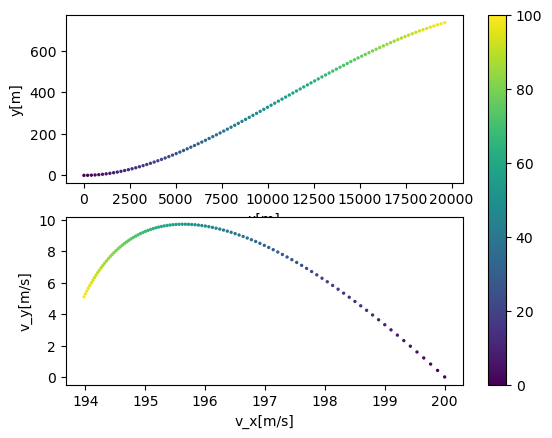

In [14]:
# 将结果画图
fig, axes = plt.subplots(2,1)
x_arr = w_arr[:,0]
y_arr = w_arr[:,1]
ax = axes[0].scatter(x_arr, y_arr, s=2, c=t_arr)
axes[0].set_xlabel('x[m]')
axes[0].set_ylabel('y[m]')

vx_arr = w_arr[:,2]
vy_arr = w_arr[:,3]
ax = axes[1].scatter(vx_arr, vy_arr, s=2, c=t_arr)
axes[1].set_xlabel('v_x[m/s]')
axes[1].set_ylabel('v_y[m/s]')

fig.colorbar(ax, ax=axes)

这里的例子，我们介绍了如何将二阶常微分方程转换为一阶常微分方程组，同样的方法适用于更高维的情况。

## 误差分析

与数值微积分算法类似，由于使用有限的步长，常微分方程算法也会有近似误差，其中又可以分为两类误差来衡量算法的优劣：
- 局部近似误差(local truncation error, LTE)，表征算法对步长$h$的敏感程度，如果误差依赖于$h^n$，则是n阶精度的算法，n越高，算法效率越高。
- 累积近似误差(cumulative truncation error, CTE)：表征算法积分一定步长后的累积近似误差，如果计算每一步的局部近似误差有一个偏向，则误差会随步长增加而积累，导致最终结果与精确结果偏差很大。

对于累积近似误差CTE，我们在数值微积分中并未提到，主要是因为数值微积分中的函数$f(x)$是已知的：
- 对微分来说，对给定$x$位置的微分只依赖于$x$附近的函数值，因此没有累积误差的概念；
- 对一个大区间的积分，如果使用复化积分，每个子区间的积分是相互独立的，不受其他区间积分的影响，最终将所有区间结果加起来时，整体累积的误差与子区间积分局部误差成正比，通常取决于局部误差最大的区间。

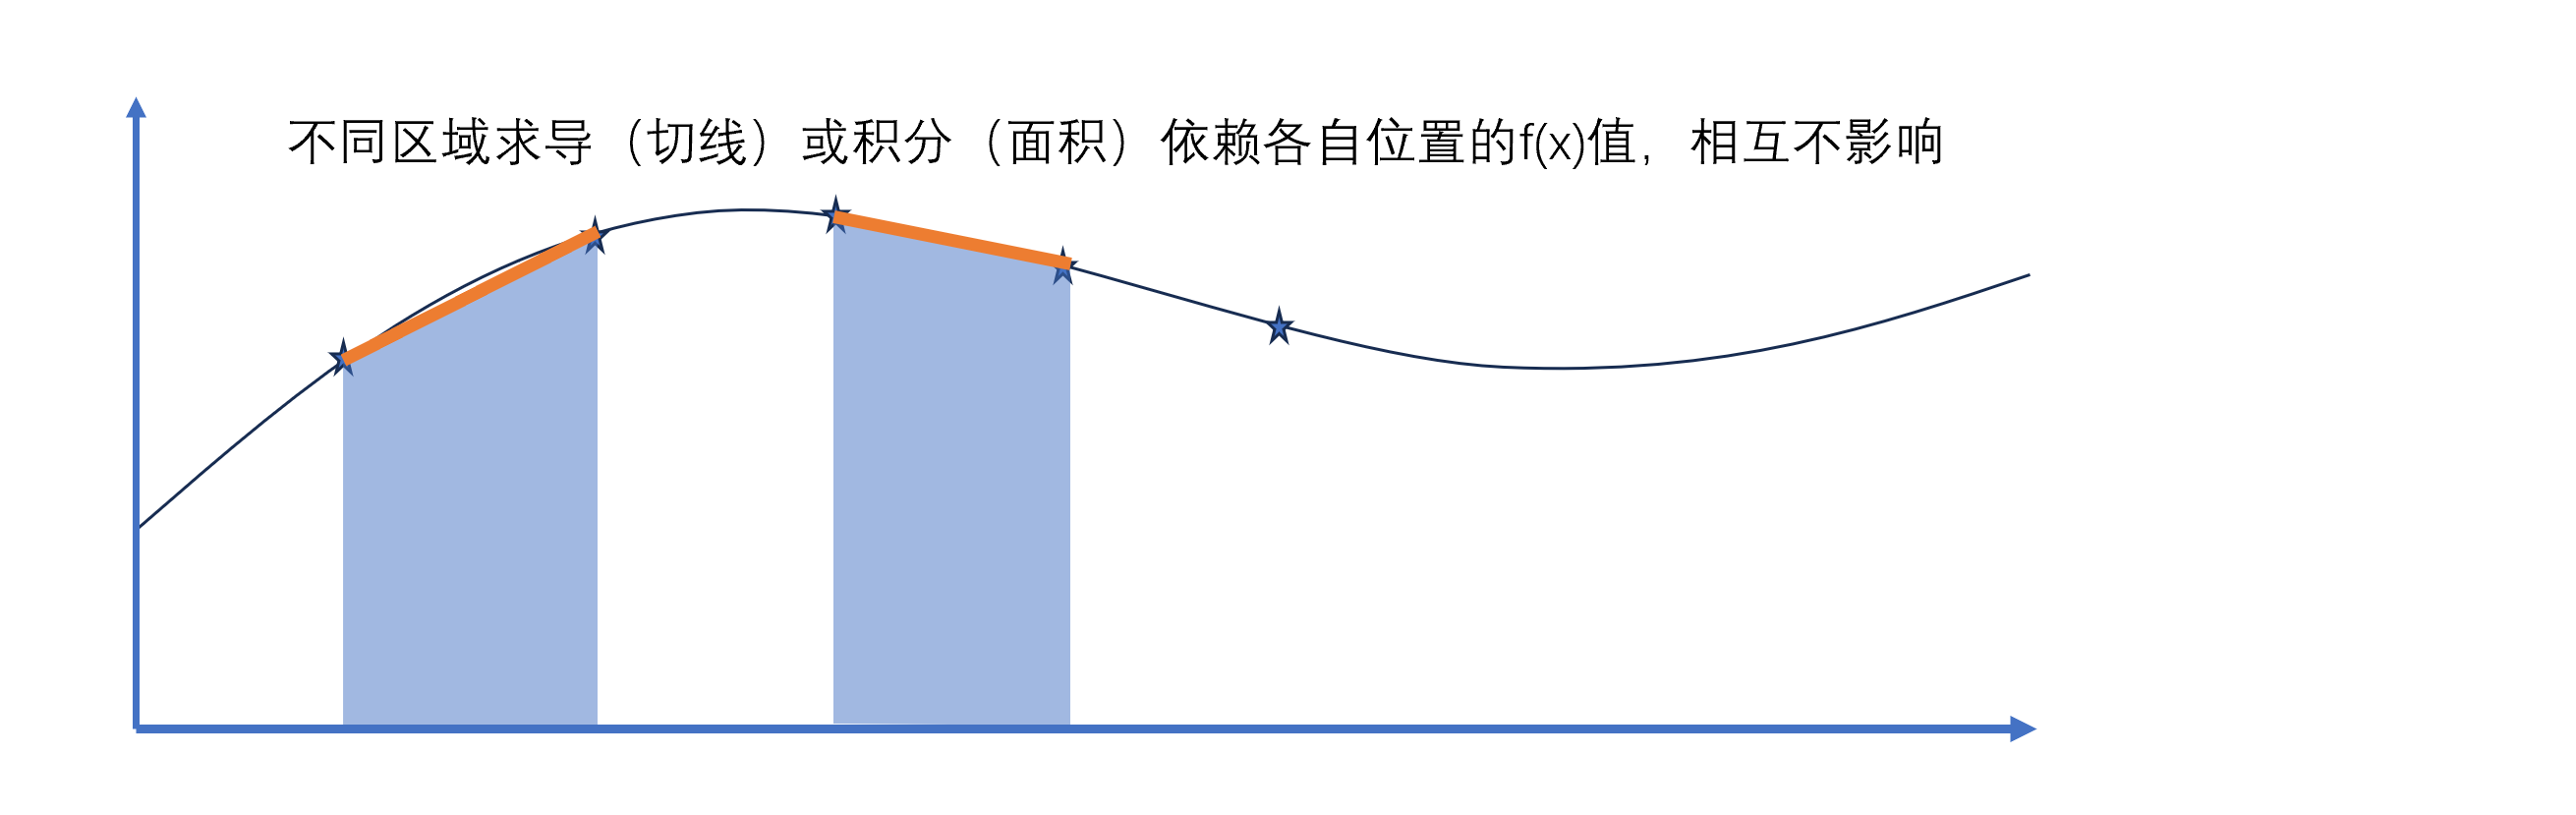

但对于常微分方程：

$F(t, y, y', y'', \ldots, y^{(n)}) = 0$

其中的待求解函数$y(t)$是未知的。求解$y$的过程实际上是一个前后依赖的迭代过程：下一个$y(t_{i+1})$依赖于上一个求解到的$y(t_i)$。

如果$y(t_i)$计算不准确，$y(t_{i+1})$就会继承这一误差。如果算法比较优秀，例如$y(t_i)$误差是正数，$y(t_{i+1})$则是大小相近的负数，则误差在传递中会相互抵消，使最终的累积误差CTE与局部误差LTE相差不大；但如果迭代过程中误差始终为正或为负，误差就会不断累积放大。CTE对具有周期性的物理问题会产生严重影响，需特别注意。

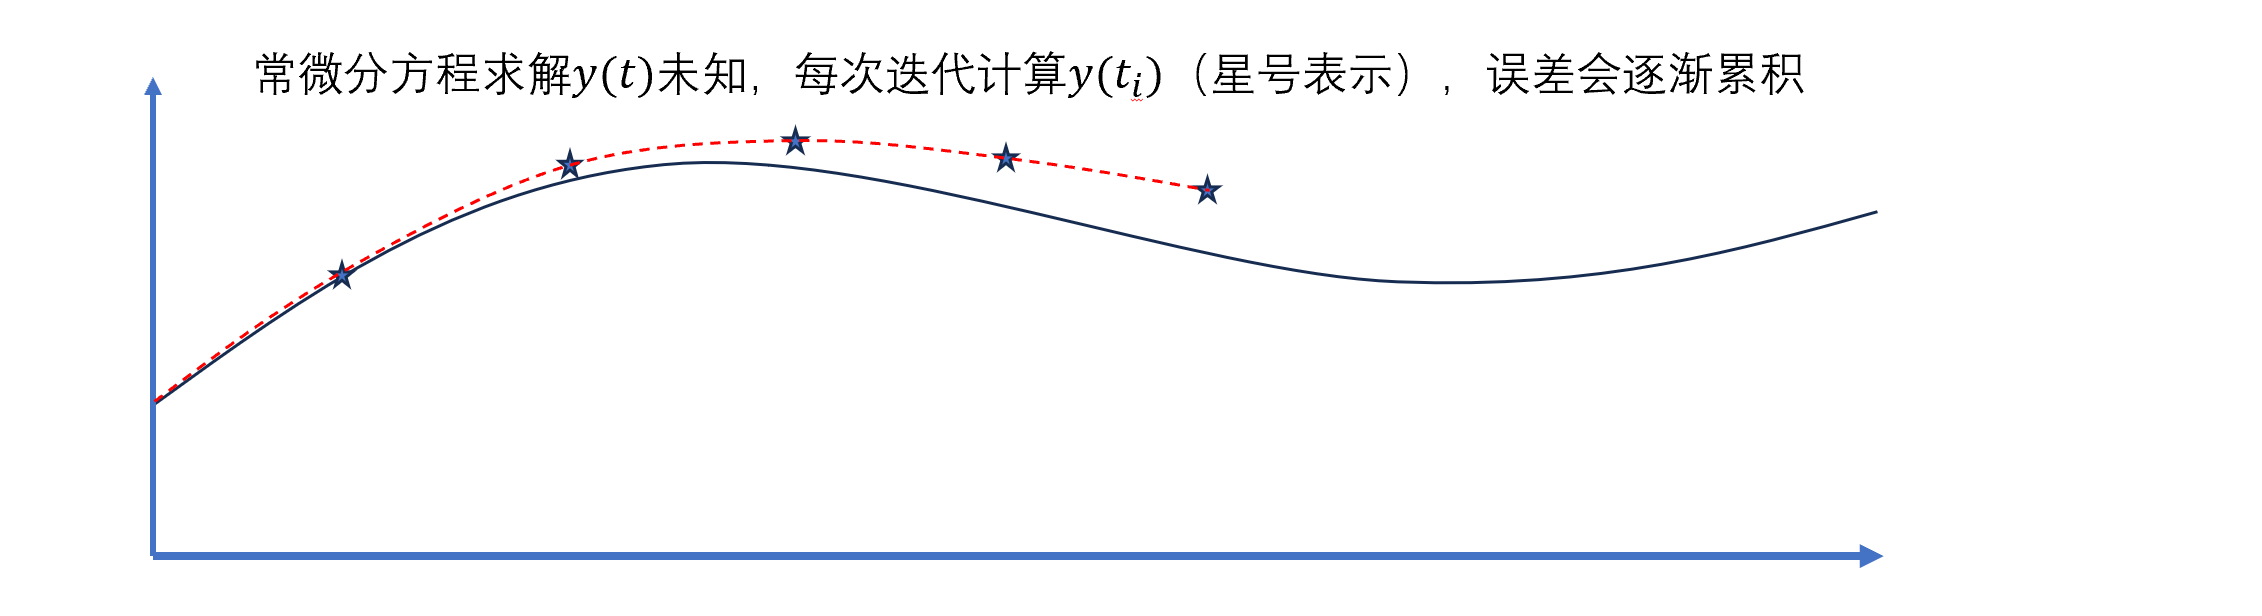

为分析算法两种误差，我们生成两个函数，分别用于获得LTE和CTE并画图分析：

- 局部误差分析函数：

In [1]:
def LTE_analysis(axes, odeint, dydt_func, y_func, t0, hmax, ndim=1, ndiv=6, nstep=1, pre_nstep=1, func_args=(), labels=[''], linestyle='-', color=None, **ode_kwargs):
    
    """
    选取不同步长，对比精确函数值y_func与odeint求解dydt_func结果中的第一步局部误差，画出误差对步长的依赖关系
    并用scipy.optimize.curve_fit拟合分析
    
    参数:
    -------------
    axes: 绘图坐标轴列表，列表每个元素为一个绘图ax，分别对应y中每个成员的画图
    odeint: 常微分方程（ODE）求解器函数
    dydt_func: dy/dt = f(t,y) 的函数形式
    y_func: dy/dt = f(t,y) 的解析解 y(t)
    t0: t的起始点
    hmax: 测试用最大步长
    
    可选参数：
    -------------
    ndim: y函数的维度，默认为1（标量）
    ndiv: 用于测试 h 依赖性的步长分割总数，默认5
    nstep: 测试积分步数，默认1（取最后一步测量误差）
    pre_nstep: 对多步法，需要前几步作为初值时，可指定需要的步数，默认只有一个初值 1
    func_args: y_func 和 dydt_func 的额外参数，默认空元组
    labels: 画图中数据的标签列表，其中元素指代每个y向量的成员，默认无字符''
    linestyle：画图中的线类型，默认为'-'
    color: 画图中的颜色，默认自动

    关键词参数:
    -----------------
    ode_kwargs: 用于odeint 的关键词参数
    
    """
    
    # 使用不同步长求解，并与精确y函数值比较，得到最大局部误差
    hlist = [] # 步长列表
    elist = [] # 对应不同步长的LTE列表
    
    for i in range(ndiv):

        # 计算步长
        h = hmax/2**i   

        # 以步长h生成t列表
        tlist =  np.linspace(t0, t0+h*nstep, nstep+1)
        
        # 精确值
        ylist_accurate = y_func(tlist, *func_args)

        # 如果返回为一维，拓展为二维，与ODE返回保持一致，方便后面计算
        if (len(ylist_accurate.shape)==1):
            ylist_accurate = ylist_accurate[:,None]
        
        # 求解ODE
        if (pre_nstep==1):
            # y0 初值为精确解第一个值 
            y0 = ylist_accurate[0]
            ylist_ode = odeint(dydt_func, y0, tlist, args = func_args, **ode_kwargs)        
        else:
            # y0 初值为前pre_nstep个值
            y0 = ylist_accurate[:pre_nstep+1]
            ylist_ode = odeint(dydt_func, y0, tlist[pre_nstep:], args = func_args, **ode_kwargs)        
        
        # 得到局部误差
        error = np.abs(ylist_ode[-1] - ylist_accurate[-1])
        
        # 将结果存入hlist和elist
        hlist.append(h)
        elist.append(error)

    # 将列表转为numpy数组，便于分析
    hlist = np.array(hlist)
    elist = np.array(elist)
   
    # 创建拟合函数，分析误差对h的依赖，拟合函数在对数空间中操作
    from scipy.optimize import curve_fit
    fit_func = lambda logh, order, const: order*logh + const
    
    # 在axes每个子图上，循环y中每个成员的误差画图，并拟合分析
    for i in range(ndim):
        
        # h-err图
        axes[i].plot(hlist, elist[:,i], 'x', color=color)
    
        # 对数空间下拟合h^n
        popt, pcov = curve_fit(fit_func, np.log(hlist), np.log(elist[:,i]))
        
        # 使用拟合结果计算拟合曲线，并画图，在曲线标签中标明h^n，n为拟合到的值
        efit = np.exp(fit_func(np.log(hlist), *popt))        
        axes[i].plot(hlist, efit, linestyle, color=color, label = (r'%s ($h^{%.0f})$' % (labels[i], popt[0])))
        
        # 画图转为对数空间
        axes[i].set_xscale('log')
        axes[i].set_yscale('log')
        axes[i].legend()
        axes[i].set_ylabel('LTE')
   
    axes[-1].set_xlabel('h')


- 累积误差分析函数：类似局部误差分析函数，画出累积误差对步长的依赖

In [2]:
def CTE_analysis(axes, odeint, dydt_func, y_func, t0, tf, nstep_min, ndim=1, ndiv=6, pre_nstep=1, func_args=(), labels=[''], linestyle='-', color=None,  **ode_kwargs):
    
    """
    选取不同步长，对比精确函数值y_func与odeint求解dydt_func结果中的累积误差，画出误差对步长的依赖关系
    并用scipy.optimize.curve_fit拟合分析
    
    参数:
    -------------
    axes: 绘图坐标轴列表，列表每个元素为一个绘图ax，分别对应y中每个成员的画图
    odeint: 常微分方程（ODE）求解器函数
    dydt_func: dy/dt = f(t,y) 的函数形式
    y_func: dy/dt = f(t,y) 的解析解 y(t)
    t0: t的起始点
    tf: t的结束点
    nstep_min: 从t0到tf分割的最小步数(>=1) 
    
    可选参数：
    -------------
    ndim: y函数的维度，默认为1（标量）
    ndiv: 用于测试 h 依赖性的步长分割总数，默认5
    pre_nstep: 对多步法，需要前几步作为初值时，可指定需要的步数，默认只有一个初值 1
    func_args: y_func 和 dydt_func 的额外参数，默认空元组
    labels: 画图中数据的标签列表，其中元素指代每个y向量的成员，默认无字符''
    linestyle：画图中的线类型，默认为'-'
    color: 画图中的颜色，默认自动

    关键词参数:
    -----------------
    ode_kwargs: 用于odeint 的关键词参数
    
    """
    
    # 使用不同步长求解，并与精确y函数值比较，得到最大局部误差
    hlist = [] # 步长列表
    elist = [] # 对应不同步长的LTE列表
    
    for i in range(ndiv):

        # 计算步长总数
        nstep = nstep_min*2**i

        # 计算步长
        h = (tf-t0)/nstep
        
        # 以生成t列表
        tlist =  np.linspace(t0, tf, nstep+pre_nstep)
        
        # 精确值
        ylist_accurate = y_func(tlist, *func_args)

        # 如果返回为一维，拓展为二维，与ODE返回保持一致，方便后面计算
        if (len(ylist_accurate.shape)==1):
            ylist_accurate = ylist_accurate[:,None]
        
        # 求解ODE
        if (pre_nstep==1):
            # y0 初值为精确解第一个值 
            y0 = ylist_accurate[0]
            ylist_ode = odeint(dydt_func, y0, tlist, args = func_args, **ode_kwargs)        
        else:
            # y0 初值为前pre_nstep个值
            y0 = ylist_accurate[:pre_nstep+1]
            ylist_ode = odeint(dydt_func, y0, tlist[pre_nstep:], args = func_args, **ode_kwargs)   
        
        # 得到最后一个值为累积误差
        error = np.abs(ylist_ode[-1] - ylist_accurate[-1])
        
        # 将结果存入hlist和elist
        hlist.append(h)
        elist.append(error)

    # 将列表转为numpy数组，便于分析
    hlist = np.array(hlist)
    elist = np.array(elist)
   
    # 创建拟合函数，分析误差对h的依赖，拟合函数在对数空间中操作
    from scipy.optimize import curve_fit
    fit_func = lambda logh, order, const: order*logh + const
    
    # 在axes每个子图上，循环y中每个成员的误差画图，并拟合分析
    for i in range(ndim):
        
        # h-err图
        axes[i].plot(hlist, elist[:,i], 'x', color=color)
    
        # 对数空间下拟合h^n
        popt, pcov = curve_fit(fit_func, np.log(hlist), np.log(elist[:,i]))
        
        # 使用拟合结果计算拟合曲线，并画图，在曲线标签中标明h^n，n为拟合到的值
        efit = np.exp(fit_func(np.log(hlist), *popt))        
        axes[i].plot(hlist, efit, linestyle, color=color, label = (r'%s ($h^{%.0f})$' % (labels[i], popt[0])))
        
        # 画图转为对数空间
        axes[i].set_xscale('log')
        axes[i].set_yscale('log')
        axes[i].legend()
        axes[i].set_ylabel('CTE')
   
    axes[-1].set_xlabel('h')


- 累积误差绘图函数：画出y的ODE解与精确值，以及累积误差图

In [3]:
def CTE_plot(axes, odeint, dydt_func, y_func, tlist, ndim=1, pre_nstep=1, func_args=(), labels=[''], **ode_kwargs):
    """
    分析ODE结果并画图展示y(x)与累积误差
    
    参数：
    -------------
    axes: 绘图坐标轴列表，是一个二维列表，共两行，每行对应不同y中的成员，上一行为y(x)图，下一行为累计误差图
    odeint: 常微分方程（ODE）求解器函数
    dydt_func: dy/dt = f(y,t,...) 的函数形式
    y_func: dy/dt = f(y,t,...) 的解析解 y(t,...)
    xlist: x的数据点
    
    可选参数：
    -------------
    ndim: y函数的维度，默认为1（标量）
    pre_nstep: 对多步法，需要前几步作为初值时，可指定需要的步数，默认只有一个初值 1
    func_args: y_func 和 dydt_func 的额外参数，默认空元组
    labels: 画图中数据的标签列表，其中元素指代每个y向量的成员，默认无字符''
    
    关键词参数:
    -----------------
    ode_kwargs: 用于odeint 的关键词参数
    
    """            
    
    # 精确值
    ylist_accurate = y_func(tlist, *func_args)
    
    # 如果返回为一维，拓展为二维，与ODE返回保持一致，方便后面计算
    if (len(ylist_accurate.shape)==1):
        ylist_accurate = ylist_accurate[:,None]
        
    # 求解ODE
    if (pre_nstep==1):
        # y0 初值为精确解第一个值 
        y0 = ylist_accurate[0]
        ylist_ode = odeint(dydt_func, y0, tlist, args = func_args, **ode_kwargs)        
        
        # 得到累积误差
        error = ylist_ode - ylist_accurate
    else:
        # y0 初值为前pre_nstep个值
        y0 = ylist_accurate[:pre_nstep+1]
        ylist_ode = odeint(dydt_func, y0, tlist[pre_nstep:], args = func_args, **ode_kwargs)   
        
        # 得到累积误差
        error = ylist_ode - ylist_accurate[pre_nstep:]
    
    
    # 在每个axes子图上画出
    for i in range(ndim):
        # y(x)图
        axes[0][i].plot(tlist, ylist_ode[:,i], 'x',label=labels[i])
        axes[0][i].plot(tlist, ylist_accurate[:,i], '-')
        axes[0][i].set_ylabel('y(t)')

        # CTE图
        axes[1][i].plot(tlist, error[:,i], '-',label=labels[i])
        axes[1][i].set_ylabel('CTE')
        axes[1][i].set_xlabel('t')


### `odeint`的累积近似误差

`odeint`的求解过程包含自适应控制，可以让积分结果满足给定的局部近似误差，由参数`rtol`决定，默认值为1.49012e-8，即保证误差在$10^{-8}$量级。我们可以考察其在默认情况下，累积近似误差的表现。首先我们选择一个有解析解的阻尼运动常微分方程：

$ \frac{d \mathbf{v}}{dt} - k v = 0 $ 

其解析解为

$ v(t) = v(0) e^{-kt}$

我们可以取初始速度$v(0)=1$,参数$k=0.01$，以下用lambda快速定义dvdt_func和v_func

In [4]:
# 定义函数
dvdt_func = lambda v,t: -0.01*v
v_func = lambda t: np.exp(-0.01*t)

带入累积误差分析函数，情况，可以看到累积误差存在正方向的系统性偏移

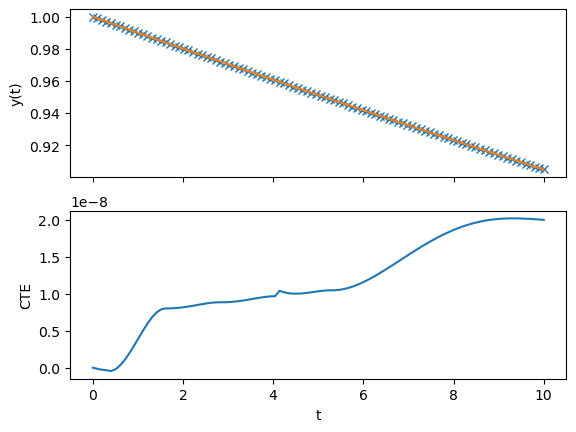

In [13]:
# 画图准备
fig, axes = plt.subplots(2,1, sharex=True, dpi=100)
axes = axes[:,None] #只有一个子图时，我们手动放入一个列表里

tlist = np.linspace(0,10,100)
CTE_plot(axes, odeint, dvdt_func, v_func, tlist, labels=['SciPy odeint'])

## 常微分方程求解算法

### 使用quad函数构建常微分方程求解函数

在常微分方程求解思路中，我们介绍了常微分方程是利用数值积分不断迭代实现的：

$y(t_{n+1}) = y(t_n) + \int_{t_n}^{t_{n+1}} {y'(t) d t}$

`scipy.integrate.quad`是能够实现数值积分，我们可以利用quad函数来构建求解一阶一维常微分方程的函数`odeint_quad`,帮助理解常微分求解的基本原理。

我们在`odeint_quad`中，设定四个类似`odeint`的基本参数：`func, y0, t, args`，具体实现如下：

In [3]:
from scipy.integrate import quad
import numpy as np
def odeint_quad(func, y0, t, args=()):
    """
    func: 常微分方程导函数y'(t)
    y0: 初始条件
    t: 时间点数组或列表
    args: func除y,t之外的参数，默认为空()

    返回：y求解值数组
    """

    # 初始化ylist，用于存储每部迭代的y值，第一个值为初始值y0
    ylist = [y0]

    # 定义第一次积分区间的下限，为 t中第一个值
    tstart = t[0]

    # 循环迭代积分，实现求解
    for ti in t[1:]:
        # 定义本次积分区间的上限，从 t的第二值开始取
        tend = ti

        # 读取上一次积分结果y
        ylast = ylist[-1]

        # 使用quad函数是对时间t的积分，要求被积函数首参数为t，但func(y,t,...)的第一个参数为y，
        # 因此需要定义新函数quad_func，将t作为首个参数，可通过lambda函数实现，将y和args一并传入
        # 注意func本身可依赖y，但这里近似假设y在func积分过程中不变，始终为前一步的值ylast
        quad_func = lambda t: func(ylast, t, *args)
        
        # 使用quad实现从tstart到tend的积分，返回积分值dy和误差err
        dy, err = quad(quad_func, tstart, tend)

        # 新的y值为上一步值加本次积分结果dy
        y = ylast + dy
        
        # 将新值存入ylist列表
        ylist.append(y)

        # 更新下一步的积分区间的下限
        tstart = tend

    # 将ylist转换为numpy array并返回
    return np.array(ylist)

带入odeint实例1，可对比与原odeint的积分结果差别：

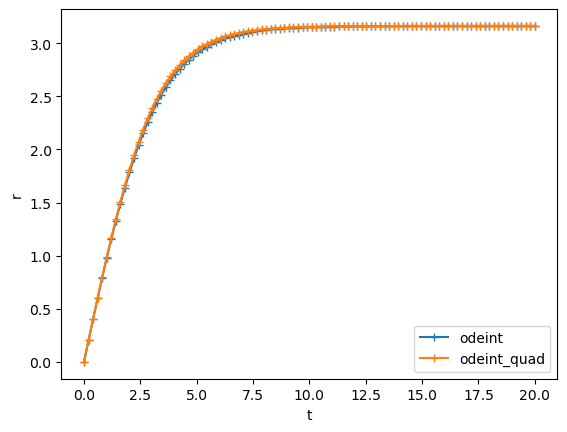

In [8]:
# 微分方程
def dvdt(v, t, f, m, k):
    return (f - k*v**2)/m

# 初始条件与参数
v0 = 0
m = 1
k = 0.1
f = 1

# 时间点数组
t_arr = np.linspace(0,20,100)

# 两种方法积分
v_arr1 = odeint(dvdt, v0, t_arr, args=(f, m, k))
v_arr2 = odeint_quad(dvdt, v0, t_arr, args=(f, m, k))

# 画图对比，可看到my_odeint与odeint的结果基本吻合
fig, axes = plt.subplots(1,1)
axes.plot(t_arr, v_arr1, '-+', label='odeint')
axes.plot(t_arr, v_arr2, '-+', label='odeint_quad')
axes.set_xlabel('t')
axes.set_ylabel('r')
axes.legend()

这里利用quad实现常微分方程求解目的是帮助大家理解常微分方程求解是如何依赖数值积分的，但实用性不高。仔细注意会发现在求解过程中，我们需要假设y'(t)函数中的y是个常数，并为上一步的结果，这并不自洽。同时，该算法效率不高，以下我们将进一步讲解更常用的常微分方程求解算法。

如果查看`odeint`的官方文档，可以找到使用的算法有以下两种类型：

- vcode, lsoda： 对非刚性（non-stiff）问题，使用隐式亚当斯法(implicit Adams)；对刚性(stiff)问题，使用基于向后微分公式的方法 (backward differentiation formulas (BDF) )  
- dopri5, dop853：显式龙格-库塔法（explicit runge-kutta method of order (4)5, 8(5,3)），包含步长控制和子步长结果输出（dense output）

这里的一些概念（显式/隐式，刚性）和算法，我们后面会逐步介绍。

### 显示（explicit）和 隐式（implicit）

在常微分方程（ODE）的数值解法中，"显示"（explicit）和"隐式"（implicit）是两种不同的方法，它们的区别在于下一步解的依赖项。

- 显示方法（Explicit Methods）： 在显示方法中，下一步的解$y_{i+1}$可以直接从之前的解$y_{i}, y_{i-1}, ...$中计算出，不依赖解自身$y_{i+1}$ 或之后的解 $y_{i+2}, y_{i+3},...$。这些方法的特点是计算相对简单高效，但可能需要较小的步长以确保数值稳定性。

- 隐式方法（Implicit Methods）： 在隐式方法中，下一步的解$y_{i+1}$可以依赖其自身$y_{i+1}$甚至之后的解$y_{i+2}, y_{i+3},...$，这种情况相当于需要解一个无微分的方程$f(y_{i+1})=0$ 或联立方程组$f_1(y_{i+1},y_{i+2},...)=0, f_2(y_{i+1},y_{i+2},...)=0, ...$，需要通过迭代算出$y(x_{i+1})$，这种方法效率计算效率低，但相对稳定，可以使用较大的步长。

选择显示方法还是隐式方法通常取决于解决的具体ODE问题以及计算资源的可用性。一些ODE可能更适合使用显示方法，而另一些则更适合使用隐式方法。

### 欧拉法

接下来，我们介绍最简单的ODE算法欧拉法，并分别介绍显示与隐式两种形式的欧拉法，对比其优缺点：

#### 显示欧拉法

显示欧拉法是最简单的ODE解法，同时也是精度最低的方法，其基本算法为：

$\mathbf{y}_{i+1} = \mathbf{y}_i + h f(t_i, \mathbf{y}_i)$

对应常微分方程

$y'(t) = f(t, \mathbf{y})$

这里下一步的$y$值只依赖上一步的导函数值，因此是显示方法。

通过泰勒展开，我们可以分析出其局部误差依赖：

$y(t+h) = y(t) + h y'(t) + \frac{1}{2} h^2 y''(t) + O(h^3)$

可看到，展开后前两项即为显示欧拉法，因此对应的局部误差

LTE $ = \frac{1}{2} h^2 y''(t) + O(h^3)$

说明显示欧拉法只有一阶精度，我们可以写出一个显示欧拉法ODE函数，仿照SciPy的`odeint` 参数形式:

In [24]:
def ode_explicit_euler(func, y0, tlist, args=(), savefreq=1):
    """
    显示欧拉法
    
    参数:
    ---------------
    func: myODE函数，返回 dy/dt = f(y, t)
    y0: 初始 y 值
    tlist: 自变量t数组

    可选参数：
    ------------
    args: 用于 func 的额外参数
    savefreq: 存储数据的时间间隔，默认每一个时间点都存取

    返回值: ylist: 求解出的tlist对应的y数组
    """
    
    # 初始步骤
    y = y0
    t = tlist[0]
    
    # 返回列表，存入初始值
    ylist = [y]
    
    # 记录计算步数
    nsteps = 0
    
    # ODE求解循环，从tlist第二个值开始
    for tn in tlist[1:]:
        
        # 计算导数
        dydt = func(y, tn, *args)
        
        # 步长由相邻t算出
        h = tn - t
        
        # 得到下一步值
        yn = y + dydt*h
        
        # 更新t, y
        t = tn
        y = yn
        
        # 更新步数
        nsteps += 1

        # 每savefreq存取一次
        if (nsteps%savefreq == 0):
            ylist.append(yn)
        
    return np.array(ylist)

我们以上面Scipy的odeint误差分析中的例子来分析两种误差表现：

In [10]:
# 定义函数
dvdt_func = lambda v,t: -0.1*v
v_func = lambda t: np.exp(-0.1*t)

使用之前定义的函数分析局部误差，可以看到误差与步长成一阶关系

Text(0, 0.5, 'error')

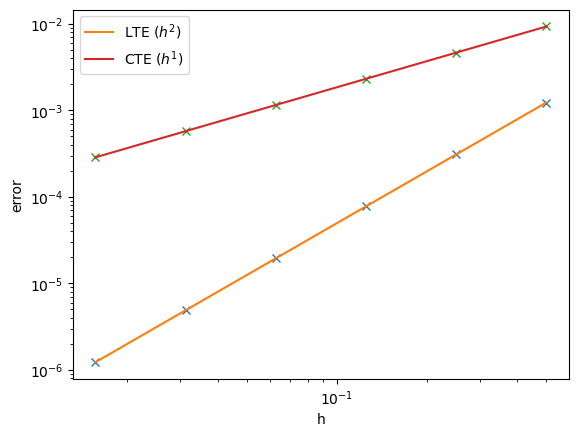

In [15]:
# 画图准备
fig, axes = plt.subplots(1,1, dpi=100)
axes = [axes] #只有一个子图时，我们手动放入一个列表里

# LTE分析，参数表： LTE_analysis(axes, odeint, dydx_func, y_func, x0, hmax, ndim=1, ndiv=5, func_args=(), ode_args=(), labels=['']):
t0 = 0
hmax = 0.5
LTE_analysis(axes, ode_explicit_euler, dvdt_func, v_func, t0, hmax, labels=['LTE'])

# CTE分析
tf = 10
nstep_min = 20
CTE_analysis(axes, ode_explicit_euler, dvdt_func, v_func, t0, tf, nstep_min, labels=['CTE'])

axes[0].set_ylabel('error')

继续查看累积误差，可以看到显示欧拉方法存在累积误差偏移问题，随着积分步长的增加，累积误差将成为不可忽略的因素

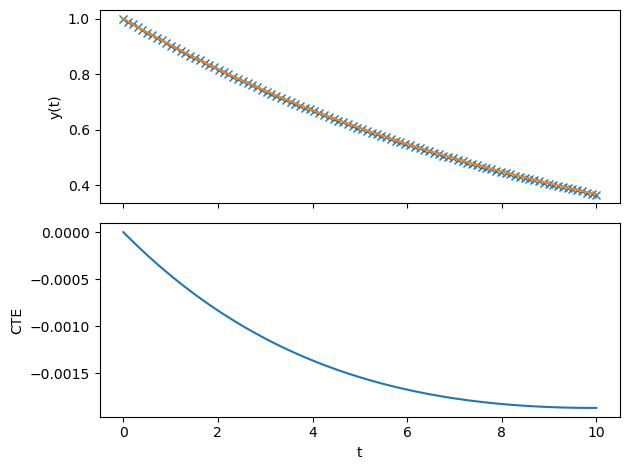

In [16]:
# 画图准备
fig, axes = plt.subplots(2,1, sharex=True)
axes = axes[:,None] #只有一个子图时，我们手动放入一个列表里

# CTE分析
tlist = np.linspace(0, 10, 100)
CTE_plot(axes, ode_explicit_euler, dvdt_func, v_func, tlist, labels=['Explicit Euler'])
plt.tight_layout()
plt.show()

#### 隐式欧拉法

隐式欧拉法是对显示方法的改进，不仅精度提高，累计误差问题也得到缓解。其基本算法为：

$\mathbf{y}_{i+1} = \mathbf{y}_i + \frac{1}{2} h \left[f(t_i, \mathbf{y}_i) + f(t_{i+1}, \mathbf{y}_{i+1})\right]$

对比显示欧拉法会发现，下一步依赖的导数$y'$不在只依赖上一步的$y_{i}$，而是上一步和这一步的平均，因此是隐式算法。这种情况，想求解$y_{i+1}$，需要先已知$y_{i+1}$算出$f(t_{i+1}, \mathbf{y}_{i+1})$，这样就必须迭代求解，首先需要预估一个$y_{i+1}$，再通过迭代修正$y_{i+1}$，具体做法为：

1. 使用显示方法预测下一步解：$y_{i+1,p} = \mathbf{y}_i + h f(t_i, \mathbf{y}_i)$
2. 将预测值带入隐式欧拉法中，得到修正后的解：$y_{i+1} = \mathbf{y}_i + \frac{1}{2} h \left[f(t_i, \mathbf{y}_i) + f(t_{i+1}, \mathbf{y}_{i+1,p})\right]$
3. 此时修正值$y_{i+1}$与预测值$y_{i+1,p}$会有差异，因此并不严格符合隐式欧拉公式的定义，我们可以将修正值$y_{i+1}$代替预测值带入隐式欧拉公式中继续算出更精确的$y_{i+1}$，这一过程可以多次迭代不断提高精度。

隐式欧拉法有俩个重要改进处：
1. 比显示方法高了一个精度，是局部近似误差为3阶的方法
2. 具有**反演对称性**，在周期性问题中，能有效抑制累计误差

这里我们说明以下什么是反演对称性。隐式欧拉法如果从$i+1$反向求解$i$，我们会发现其公式为：

$\mathbf{y}_{i} = \mathbf{y}_{i+1} - \frac{1}{2} h \left[f(t_i, \mathbf{y}_i) + f(t_{i+1}, \mathbf{y}_{i+1})\right]$

与正向求解只差一个$h$的符号，形式完全对称。这种具有反演对称性的算法能有效抑制具有周期解的ODE累积误差的产生（但需要通过多次迭代才能近似实现这种对称性）。以下我们通过具体的函数实现来验证这些特征。

在隐式欧拉函数中，我们加入一个niter参数，用来表征算法第三步的迭代次数，迭代越多，结果越准确。

In [17]:
def ode_implicit_euler(func, y0, tlist, args=(), niter=0, savefreq=1):
    """
    隐式欧拉法
    
    参数:
    ---------------
    func: myODE函数，返回 dy/dt = f(y, t)
    y0: 初始 y 值
    tlist: 自变量t数组

    可选参数：
    ------------
    args: 用于 func 的额外参数，默认空
    niter: 迭代求解y的次数，默认不迭代（只用预测y_p 计算 y）
    savefreq: 存储数据的时间间隔，默认每一个时间点都存取

    返回值: ylist: 求解出的tlist对应的y数组
    """

    # 初始步骤
    y = y0
    t = tlist[0]
    dydt = func(y, t, *args)
    
    # 返回列表，存入初始值
    ylist = [y]
    
    # 记录计算步数
    nsteps = 0
    
    # ODE求解循环，从tlist第二个值开始
    for tn in tlist[1:]:

        # 步长由相邻t算出
        h = tn - t
        
        # 首先，我们需要用显示欧拉法预测解yp
        yp = y + dydt*h
        
        # 使用预测值计算导数
        dydtp = func(yp, tn, *args)
        
        # 使用隐式欧拉公式得到修正后的解yc
        yc = y + h/2*(dydt + dydtp)
        
        # 迭代修正
        for i in range(niter):
            # 使用修正值重新计算导数
            dydtp = func(yc, tn, *args)
            # 修正yc
            yc = y + h/2*(dydt + dydtp)

        # 更新
        t = tn
        y = yc
        
        # 用更新后的y重新计算导数dydt（可以不做,用预测值dydtp代替）
        dydt = func(y, t, *args)
        
        # 更新步数
        nsteps += 1

        # 每savefreq存取一次
        if (nsteps%savefreq == 0):
            ylist.append(y)
        
    return  np.array(ylist)

我们以之前的例子分析两种误差表现：

In [18]:
# 定义函数
dvdt_func = lambda v,t: -0.1*v
v_func = lambda t: np.exp(-0.1*t)

使用之前定义的函数分析局部误差，可以看到局部误差LTE与步长成3阶关系，累积误差CTE与步长成2阶关系，同时加入迭代步后，LTE与CTE都整体下降。但迭代超过1次后影响不再明显。

Text(0, 0.5, 'error')

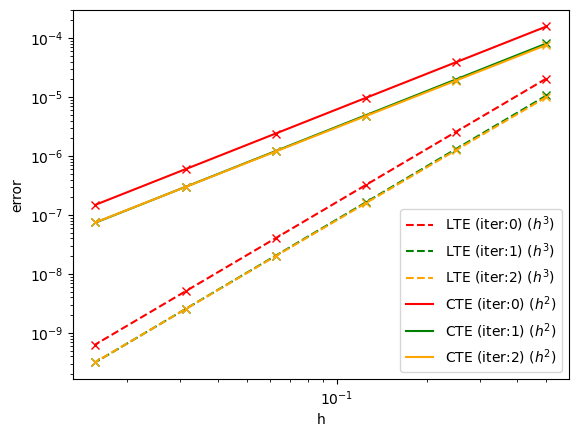

In [19]:
# 画图准备
fig, axes = plt.subplots(1,1, dpi=100)
axes = [axes] #只有一个子图时，我们手动放入一个列表里

# LTE分析，参数表： LTE_analysis(axes, odeint, dydx_func, y_func, x0, hmax, ndim=1, ndiv=5, func_args=(), ode_args=(), labels=['']):
t0 = 0
hmax = 0.5
LTE_analysis(axes, ode_implicit_euler, dvdt_func, v_func, t0, hmax, labels=['LTE (iter:0)'], linestyle='--', color='r', niter=0)
LTE_analysis(axes, ode_implicit_euler, dvdt_func, v_func, t0, hmax, labels=['LTE (iter:1)'], linestyle='--', color='g', niter=1)
LTE_analysis(axes, ode_implicit_euler, dvdt_func, v_func, t0, hmax, labels=['LTE (iter:2)'], linestyle='--', color='orange', niter=2)

# CTE 分析
tf = 10
nstep_min = 20
CTE_analysis(axes, ode_implicit_euler, dvdt_func, v_func, t0, tf, nstep_min, labels=['CTE (iter:0)'], color='r', niter=0)
CTE_analysis(axes, ode_implicit_euler, dvdt_func, v_func, t0, tf, nstep_min, labels=['CTE (iter:1)'], color='g', niter=1)
CTE_analysis(axes, ode_implicit_euler, dvdt_func, v_func, t0, tf, nstep_min, labels=['CTE (iter:2)'], color='orange', niter=2)

axes[0].set_ylabel('error')

继续查看累积误差，可以看到累积误差也有偏移，当迭代次数不同时，误差累积也会有所变化

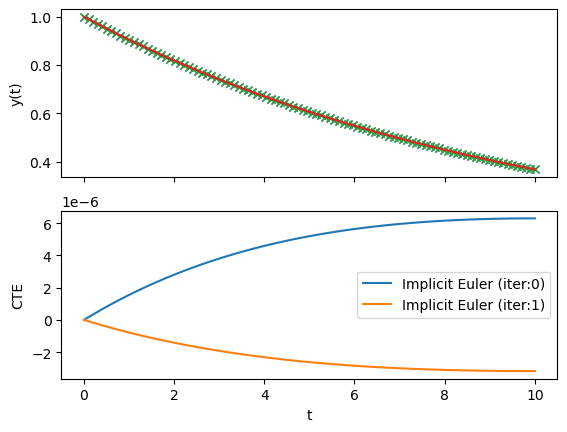

In [20]:
# 画图准备
fig, axes = plt.subplots(2,1, sharex=True, dpi=100)
axes = axes[:,None] #只有一个子图时，我们手动放入一个列表里

# LTE分析，参数表： CTE_analysis(axes, odeint, dydx_func, y_func, xlist, ndim=1, func_args=(), ode_args=(), labels=[''])
tlist = np.linspace(0,10,100)
CTE_plot(axes, ode_implicit_euler, dvdt_func, v_func, tlist, labels=['Implicit Euler (iter:0)'])
CTE_plot(axes, ode_implicit_euler, dvdt_func, v_func, tlist, labels=['Implicit Euler (iter:1)'], niter=1)
axes[1,0].legend()

### 刚性问题

在常微分方程（ODE）数值求解中，"Stiff"（刚性）问题是指一类特殊的ODE问题，其特点是在解的不同部分之间存在极大的尺度差异或快速的变化。具体来说，Stiff问题表现为以下特点：

- **尺度差异**： 在Stiff问题中，ODE中的某些项（通常是导数中的某些项）具有非常大的数值，而其他项则相对较小。这导致了ODE解中存在明显的尺度差异，即某些变量的变化非常迅速，而其他变量的变化非常缓慢。

- **快速变化**： Stiff问题中的某些解分量可能在非常短的时间内迅速振荡或变化，而其他解分量则相对稳定。这种快速变化可能导致数值方法需要选择非常小的时间步长，以捕获快速变化的细节，这会使数值求解变得非常耗时。

- **数值不稳定性**： 由于快速变化和尺度差异，一些标准的数值ODE求解方法在Stiff问题上可能会表现出数值不稳定性。这意味着数值解可能会发散或不准确，除非采用特殊的数值方法来处理刚性问题。

Stiff问题通常出现在描述物理现象的ODE中，其中某些变量具有快速的动态变化，而其他变量的变化较慢。例如，如果考虑地球上一只天鹅转圈的运动与地球绕转太阳的运动，对应的空间尺度差异巨大，同时天鹅的运动变化比地球轨道变化快几个量级，这种问题求解如果处理的不好，比如步长$h$远超过天鹅转圈的周期，会导致一步运算，鸭子就飞出地球，且其后的运动变得不可控，如果最终导致速度或位置出现极大值，超过浮点数极限，甚至导致ODE求解崩溃。

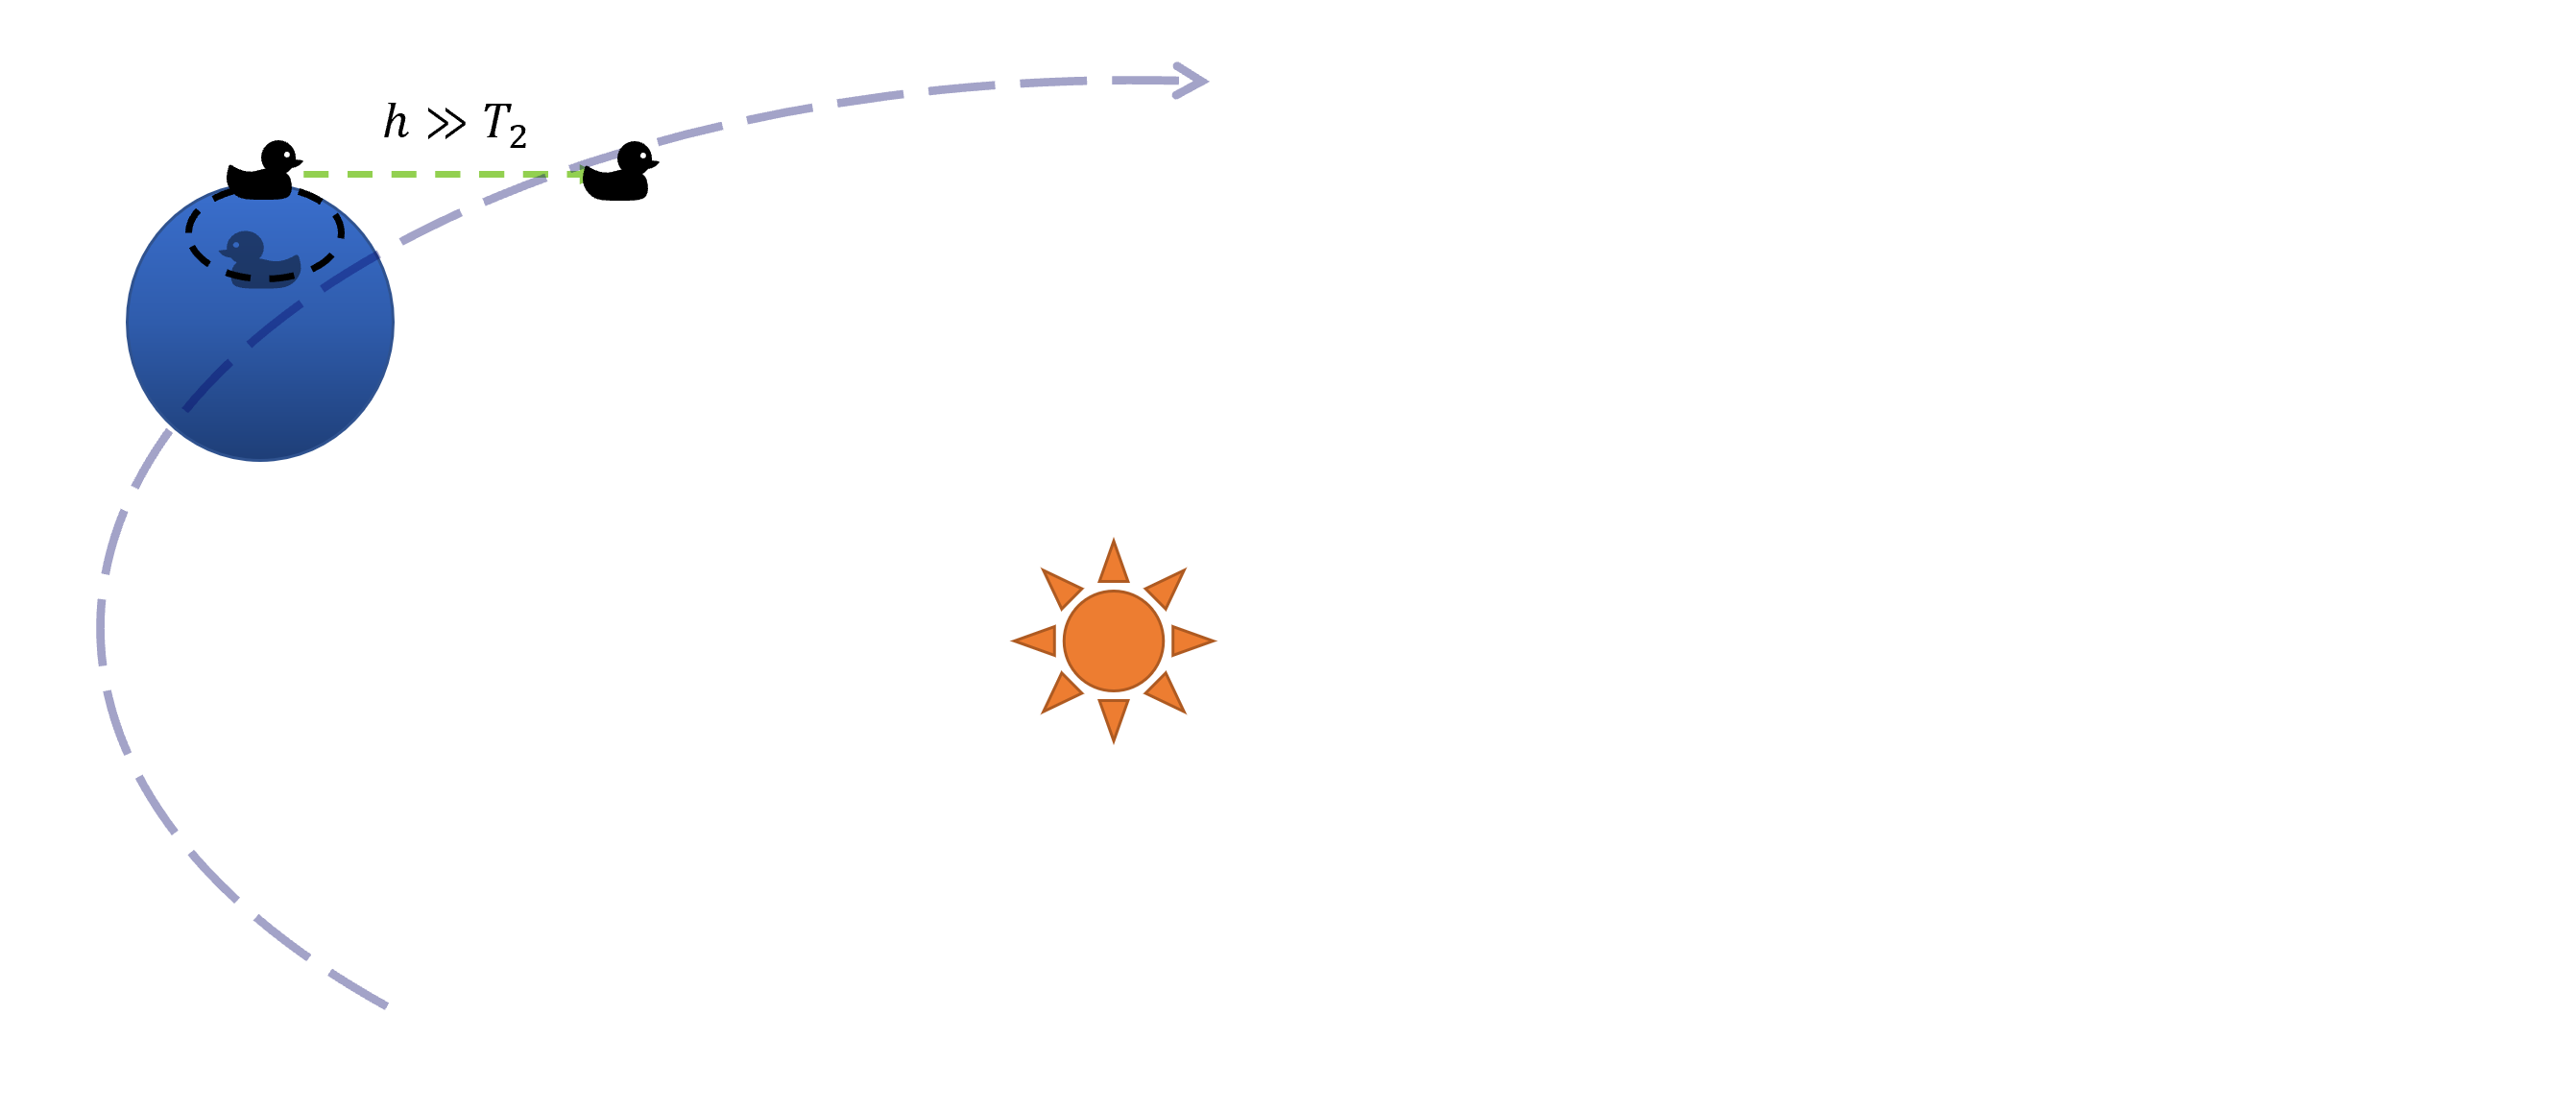

为了解决Stiff问题，需要使用专门设计用于处理刚性问题的数值ODE求解方法，例如隐式数值方法（Implicit Methods）或结合了自适应步长控制的方法。这些方法可以更好地处理快速变化和尺度差异，从而获得准确的数值解。我们用上面实现的显示与隐式欧拉法，来说明它们在处理刚性问题上的差别。

刚性问题的核心在于所求常微分方程中存在一部分小尺度或时间变化剧烈的部分，这些部分在求解过程中使用了过于大的步长，我们来模拟这样一个情况，对一个二维圆周运动使用大步长求解，看轨迹如何受算法影响而变化。

一个物体想作圆周运动，其加速度需始终与速度垂直，且大小不变，其ODE可以表示如下：

$\frac{dv}{dt} = [-k\frac{v_y}{|v|}, k\frac{v_x}{|v|}]$

$\frac{dx}{dt} = [v_x, v_y]$

其中，$k$是一个常数，表示加速度大小。我们这里为方便讨论，可以令$k$的大小为$|v|$，简化ODE方程。

另外，这是一个二阶二维ODE，可以通过实例3中的方法转换为4个一阶ODE方程，对应`w=(x,y,vx,vy)`，其导函数方程：

In [21]:
def dwdt_func(w, t):
    """
    w: (x, y, vx, vy)
    t: time
    a: coefficient
    """
    x, y, vx, vy = w
    
    vmod = np.sqrt(vx*vx + vy*vy)
    
    dvdt = [-vy, vx] # k=|v|
    drdt = [vx, vy]
    
    dwdt = drdt + dvdt
    
    return np.array(dwdt)

我们使用显示与隐式方法分别求解，隐式方法使用两次，分别迭代1次和5次

In [26]:
# 初始值
w0 = np.array([1, 0, 2, 2])

# 时间序列，其中步长间隔h=0.5
tlist = np.linspace(0,500,1000)

# 求解
ylist_e = ode_explicit_euler(dwdt_func, w0, tlist)
ylist_i1 = ode_implicit_euler(dwdt_func, w0, tlist,niter=1)   # 迭代1次
ylist_i10 = ode_implicit_euler(dwdt_func, w0, tlist,niter=10)   # 迭代10次

画出轨迹和速度图比较，可以看到三种结果有很大不同：
- 显示欧拉法在步长过大时，速度和位置指数式增长，螺旋向外，最终达到一个极大的数量级$10^48$
- 迭代1次的隐式欧拉法，虽然结果也不正确，但速度和位置都在不断减小，最终趋于螺旋中心
- 迭代10次的隐式欧拉法，表现出极好的稳定性，基本维持圆周运动，只有很小的向内偏移。

从这个例子我们可以看出高迭代的隐式方法能够有效抑制过大的累积误差，抵抗步长过大造成的不稳定性，能很好处理刚性问题。

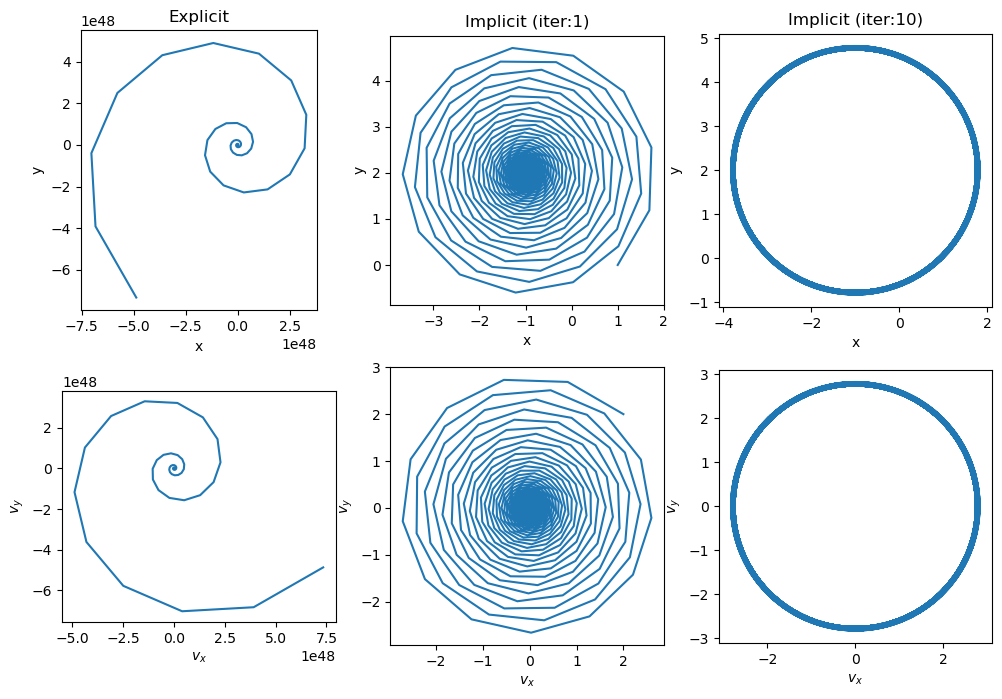

In [27]:
fig, axes = plt.subplots(2,3, figsize=(12,8))

titles = ['Explicit','Implicit (iter:1)', 'Implicit (iter:10)']
for i, ylist in enumerate([ylist_e, ylist_i1, ylist_i10]):
    x = ylist[:,0]
    y = ylist[:,1]
    axes[0][i].plot(x, y)
    axes[0][i].set_xlabel('x')
    axes[0][i].set_ylabel('y')
    axes[0][i].set_aspect(1)
    
    vx = ylist[:,2]
    vy = ylist[:,3]
    axes[1][i].plot(vx, vy)
    axes[1][i].set_aspect(1)
    axes[1][i].set_xlabel(r'$v_x$')
    axes[1][i].set_ylabel(r'$v_y$')
    axes[0][i].set_title(titles[i])

### 亚当斯（Adams）法

欧拉法是一个只依赖于上一步与本步的低阶方法，类似于线性插值。我们在介绍积分方法中的牛顿珂特斯NC公式时，知道通过多项式插值可以构建高阶的积分方法。同理，求解ODE也可以利用多项式插值实现更高精度的方法，这一类方法称为亚当斯法。其基本实现原理如下：

#### 显示亚当斯法

首先看显示欧拉法：

$\mathbf{y}_{i+1} = \mathbf{y}_i + h f(t_i, \mathbf{y}_i)$

这里计算导数时只依赖了上一步的解$y_i$，因此精度有限。但如果我们可以利用多个步骤的导函数$y'_i, y'_{i-1},...$，使用拉格朗日或牛顿多项式插值$I(y'_i, y'_{i-1},...)$来近似导函数，然后利用NC方法在$[t_i, t_{i+1}]$区间对插值函数$I$积分，这样的结果比显示欧拉法给出的精度更高（如下图示意）。

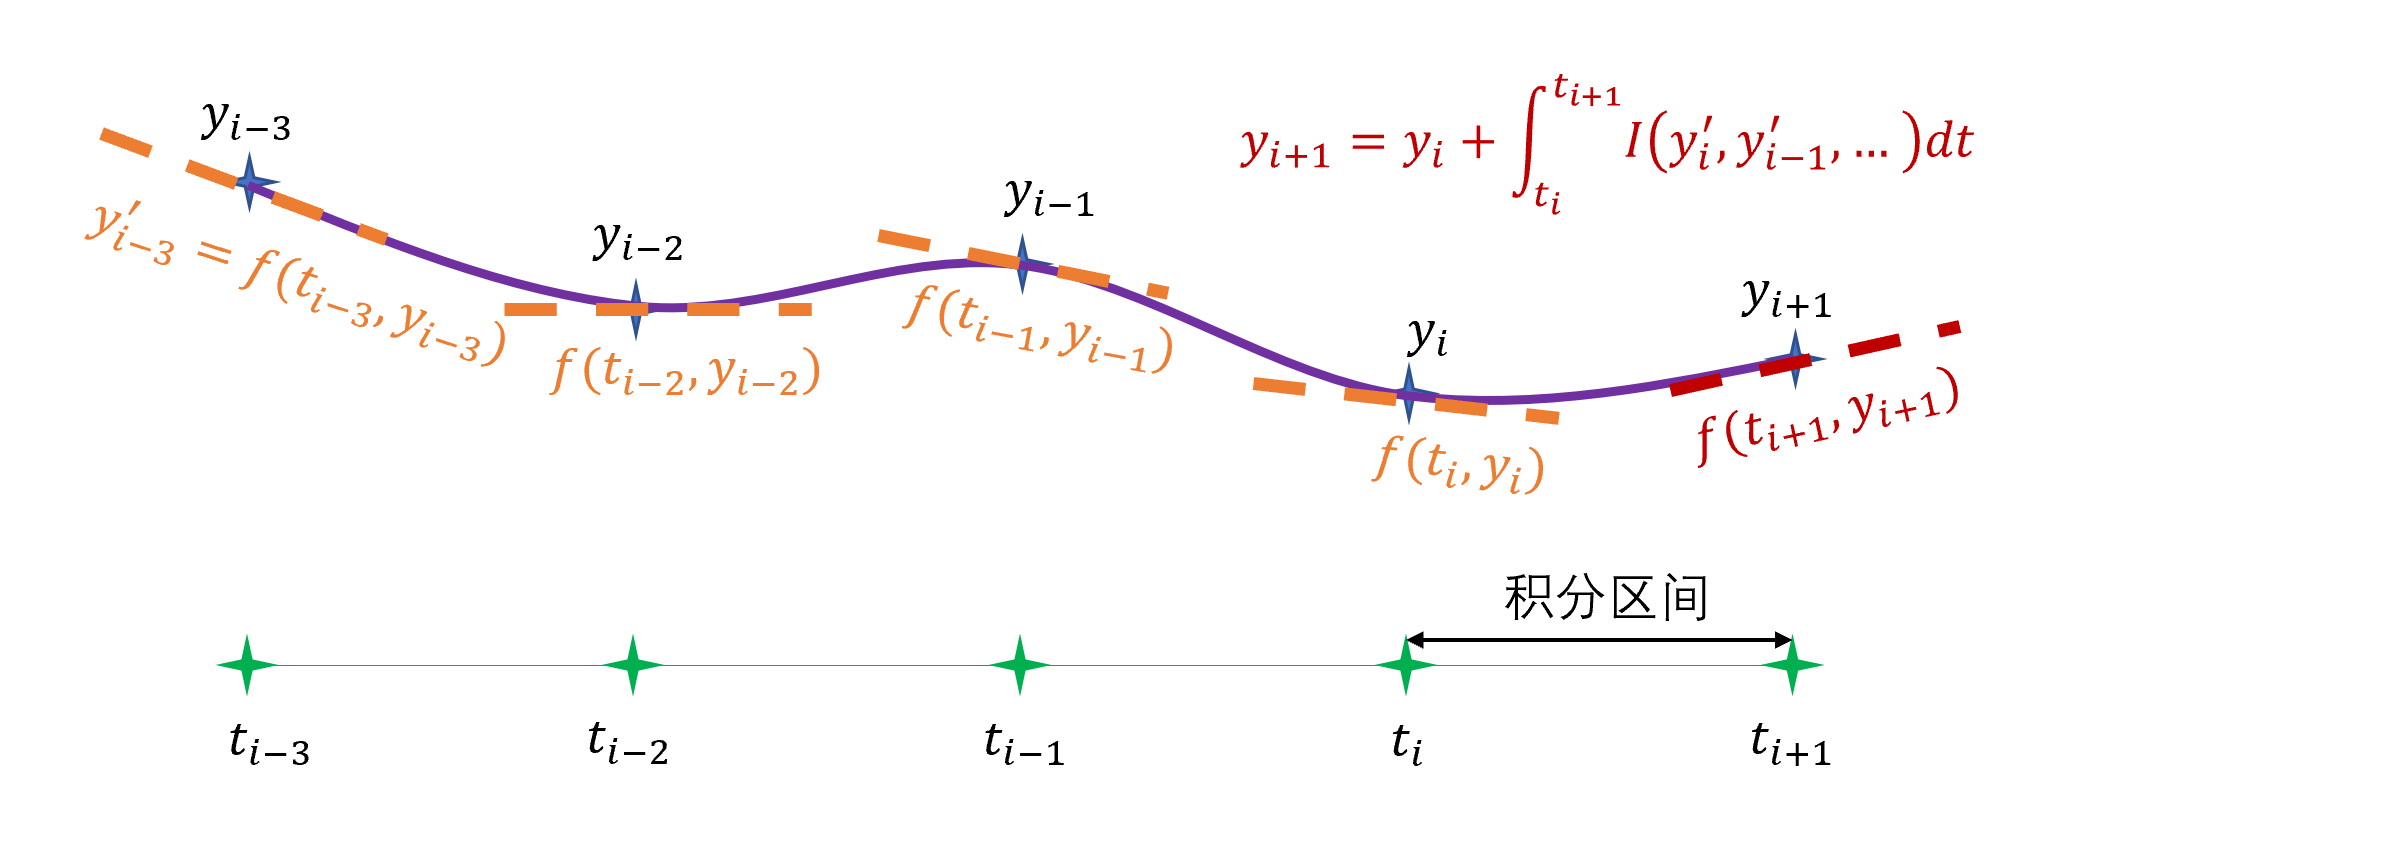

结合NC公式，我们可以给出不同阶数的显示亚当斯方法(Explicit Adams Bashforth method):

- 1阶（显示欧拉法）： $y_1 = y_{0} h$ 
- 2阶： $y_2 = y_1 - h \left(\frac{f_{0}}{2} - \frac{3 f_{1}}{2}\right)$
- 3阶：$y_3 = y_2 + h \left(\frac{5 f_{0}}{12} - \frac{4 f_{1}}{3} + \frac{23 f_{2}}{12}\right)$
- 4阶：$y_4 = y_3 - h \left(\frac{3 f_{0}}{8} - \frac{37 f_{1}}{24} + \frac{59 f_{2}}{24} - \frac{55 f_{3}}{24}\right)$

其中$f_i = f(y'_i)$, 这里的表达式可以由下面选学内容实现的函数生成。

#### 隐式亚当斯法

如果多项式插值过程还包含了需要求解的$y'_{i+1}$，则能构成隐式亚当斯法(Implicit Adams Moulton method)：

$y_{i+1} = y_{i} + \int_{t_{i}}^{t_{i+1}} I(y'_{i+1},y'_i, y'_{i-1},...) dt$

利用下面选学部分的函数生成器，我们给出前4阶的表达式：

- 1阶（隐式欧拉法）：$y_2 = y_1 + h \left(\frac{f_{0}}{2} + \frac{f_{1}}{2}\right)$
- 2阶：$y_3 = y_2 - h \left(\frac{f_{0}}{12} - \frac{2 f_{1}}{3} - \frac{5 f_{2}}{12}\right)$
- 3阶：$y_4 = y_3 + h \left(\frac{f_{0}}{24} - \frac{5 f_{1}}{24} + \frac{19 f_{2}}{24} + \frac{3 f_{3}}{8}\right)$
- 4阶：$y_5 = y_4 - h \left(\frac{19 f_{0}}{720} - \frac{53 f_{1}}{360} + \frac{11 f_{2}}{30} - \frac{323 f_{3}}{360} - \frac{251 f_{4}}{720}\right)$

##### 练习题：
可以看到，显示/隐式欧拉法也是亚当斯法中最低阶的方法。可模仿欧拉法的实现方式，实现不同阶数的亚当斯法ODE函数。

#### 亚当斯ODE函数生成器（选学）

之前介绍插值，微积分算法时，我们有通过SymPy辅助实现了多项式插值与任意阶差分与NC积分的函数生成器。由于亚当斯法是基于多项式插值和NC方法，我们可以利用之前章节已实现的函数生成器，进一步构建出亚当斯ODE函数生成器，操作如下：

首先将牛顿插值函数生成器复制过来：

In [53]:
def newton_interpolation_generator(x_array, f_array):
    """
    给定x和f数组，使用牛顿插值法生成插值函数，并最终返回这个插值函数
    
    参数:
    ---------
    x_array: x 数组，列表或元组（大小N)
    f_array: f(x) 数组，列表或元组(大小N)
    
    返回: N-1阶牛顿多项式插值函数
    """
    
    # 得到x_array大小：
    if (type(x_array) == np.ndarray):
        n = x_array.size
    elif (type(x_array) == list) | (type(x_array) == tuple):
        n = len(x_array)
    
    # 用于生成连乘序列的函数
    def dx_sequence(x,i):
        """
        prod(x - x_j) j < i
        """
        dx = 1
        for j in range(i):
            dx *= x - x_array[j]
        return dx
    
    # 用于生成i阶牛顿插值函数，其中使用了递归调用的方法
    def Ni_sum_func(x, i, ai):
        """
        sum of Ni(x)
        """
        nx = 0
        if i>0:
            nx = Ni_sum_func(x,i-1,ai) + ai[i]*dx_sequence(x,i)
        else:
            nx = ai[0]
        return nx
    
    # 插值系数
    ai = [None]*n # coefficients 
    ai[0] = f_array[0] # a1 = f1
    
    # 使用牛顿插值法计算每一阶的系数
    for i in range(1,n): 
        ai[i] = (f_array[i] - Ni_sum_func(x_array[i],i-1,ai))/dx_sequence(x_array[i],i)
    
    # 将计算出的ai系数带入生成函数，利用lambda表达式构造出只有x一个参数的最终插值函数
    Nx_func = lambda x:Ni_sum_func(x, n-1, ai)
    
    # 返回插值函数
    return Nx_func

- 显示亚当斯法（
对之前的NC积分函数生成器稍作改造，即可生成显示亚当斯法的

$y_{i+1} = y_{i} + \int_{t_{i}}^{t_{i+1}} I(y'_i, y'_{i-1},...) dt$

中的积分部分可执行函数与对应数学表达式。具体改变如下：

1. 将插值区间排除最后一个点（需求解的数据点$y_{i+1}$)
2. 将积分区间从$[a,b]$变为最后一个子区间`x_array[-2],x_array[-1]`，既$i$到$i+1$


In [54]:
def explicit_adams_bashforth_generator(order):
    import sympy as sy

    # 对应的数据点数为阶数+1
    n = order + 1
    
    # 定义a和h
    a = sy.Symbol('a')
    h = sy.Symbol('h')

    # x_i 可以表征为 a + i*h，因为a和h为Symbol类型，因此x_array也是一系列Symbol组成的表达式
    x_array = [a+i*h for i in range(n)]
    
    # 定义数据点f_array:
    f_array = [sy.Symbol('f_%d' % i) for i in range(n)]

    # 使用newton_interpolation_generator，返回插值表达式函数：
    interp_func = newton_interpolation_generator(x_array[:-1], f_array[:-1])

    # 带入x函数打印结果
    x = sy.Symbol('x')
    interp_form = interp_func(x)

    # 积分最后一个子区间
    ode_form = sy.integrate(interp_form, (x, x_array[-2], x_array[-1]))
    
    # 用sy.apart功能以h的级数形式展示：
    ode_form = sy.apart(ode_form, h)

    # 使用sy.lambdify转换积分表达式为可执行函数，参数表为f_array中的每一项和步长h
    ode_func = sy.lambdify([*f_array[:-1], h], ode_form)

    return ode_func, ode_form

利用这个函数，我们可以查看前4阶的显示亚当斯法具体表达式

In [55]:
# 1阶
adams_func, adams_form = explicit_adams_bashforth_generator(1)
adams_form

f_0*h

In [56]:
# 2阶
adams_func, adams_form = explicit_adams_bashforth_generator(2)
adams_form

-h*(f_0/2 - 3*f_1/2)

In [57]:
# 3阶
adams_func, adams_form = explicit_adams_bashforth_generator(3)
adams_form

h*(5*f_0/12 - 4*f_1/3 + 23*f_2/12)

In [58]:
# 4阶
adams_func, adams_form = explicit_adams_bashforth_generator(4)
adams_form

-h*(3*f_0/8 - 37*f_1/24 + 59*f_2/24 - 55*f_3/24)

接下来我们基于这个构造函数，生成最终的ODE函数：
- 注意亚当斯法每次积分需要之前多个步骤的值，因此初始值$y_0$不仅需要$t_0$时刻的值，还需要$t_0-i h$ ($i=1,2,...,order-1$)的值，因此初始条件要求较高。
- 如果无法获得$t_0$时刻前的初始条件，只能通过低价亚当斯方法估计前几步的值作为初值（如用1阶产生2阶的初始值，2阶产生3阶，再逐步递增到n阶），但这样会导致较大的初始误差，使后续的累积近似误差无法达到`n`阶水平，通常会降到(1-2阶)。

In [59]:
def ode_explicit_adams(func, y0, tlist, args=(), order=4):
    """
    显示亚当斯法
    
    参数:
    ---------------
    func: myODE函数，返回 dy/dt = f(y, t)
    y0: 初始及之前的y值数组，注意随阶数不同，初值包含个数不同，
    tlist: 自变量t数组

    可选参数：
    ------------
    args: 用于 func 的额外参数
    order: 亚当斯法的阶数，默认4

    返回值: ylist: 求解出的tlist对应的y数组
    """

    # 利用刚才构造的生成器，生成order阶的亚当斯方法
    adams_func = explicit_adams_bashforth_generator(order)[0]

    t = tlist[0]
    y = y0[-1]

    # 需要创造一个列表，用来记住前几步的导函数值，初始步利用y0数组计算
    dydt_list = func(y0, t, *args)

    # 记录y值列表
    ylist = [y0[-1]]

    # 积分循环
    for tn in tlist[1:]:
        
        # 计算步长
        h = tn - t
        
        # 当前时间
        t = tn

        # 亚当斯法积分
        y = y + adams_func(*dydt_list[-order:], h)
        ylist.append(y)

        # 计算下一步dydt
        dydt = func(y, t, *args)
        
        # 将dydt存入dydt_list
        dydt_list = np.append(dydt_list, dydt)
        
    return np.array(ylist)

我们对显示亚当斯生成函数稍加改造，既插值区间包含所有$f_i$，即可生成隐式方法

In [60]:
def implicit_adams_bashforth_generator(order):
    import sympy as sy

    # 对应的数据点数为阶数+1
    n = order + 1
    
    # 定义a和h
    a = sy.Symbol('a')
    h = sy.Symbol('h')

    # x_i 可以表征为 a + i*h，因为a和h为Symbol类型，因此x_array也是一系列Symbol组成的表达式
    x_array = [a+i*h for i in range(n)]
    
    # 定义数据点f_array:
    f_array = [sy.Symbol('f_%d' % i) for i in range(n)]

    # 使用newton_interpolation_generator，返回插值表达式函数：
    interp_func = newton_interpolation_generator(x_array, f_array)

    # 带入x函数打印结果
    x = sy.Symbol('x')
    interp_form = interp_func(x)

    # 积分最后一个子区间
    ode_form = sy.integrate(interp_form, (x, x_array[-2], x_array[-1]))
    
    # 用sy.apart功能以h的级数形式展示：
    ode_form = sy.apart(ode_form, h)

    # 使用sy.lambdify转换积分表达式为可执行函数，参数表为f_array中的每一项和步长h
    ode_func = sy.lambdify([*f_array, h], ode_form)

    return ode_func, ode_form

查看前4阶表达式：

In [61]:
# 1阶
adams_func, adams_form = implicit_adams_bashforth_generator(1)
adams_form

h*(f_0/2 + f_1/2)

In [62]:
# 2阶
adams_func, adams_form = implicit_adams_bashforth_generator(2)
adams_form

-h*(f_0/12 - 2*f_1/3 - 5*f_2/12)

In [63]:
# 3阶
adams_func, adams_form = implicit_adams_bashforth_generator(3)
adams_form

h*(f_0/24 - 5*f_1/24 + 19*f_2/24 + 3*f_3/8)

In [64]:
# 4阶
adams_func, adams_form = implicit_adams_bashforth_generator(4)
adams_form

-h*(19*f_0/720 - 53*f_1/360 + 11*f_2/30 - 323*f_3/360 - 251*f_4/720)

#### 测试显示亚当斯法的近似误差

我们测试不同阶显示亚当斯方法对局部误差的表现，可以看到局部近似误差符合阶数的预期，但达到这样的精度需要有n步初始值

In [65]:
# 定义函数
dvdt_func = lambda v,t: -0.1*v
v_func = lambda t: np.exp(-0.1*t)

In [66]:
# 画图准备
fig, axes = plt.subplots(1,1,dpi=100)
axes = [axes] #只有一个子图时，我们手动放入一个列表里

t0 = 0
hmax = 2
# 循环不同阶数的亚当斯法，看对h的依赖
for order in range(1,7):
    LTE_analysis(axes, ode_explicit_adams, dvdt_func, v_func, t0, hmax, ndiv=6, pre_nstep=order, nstep=order+1, labels=['E-Adams order: %d' % order], order=order)

#### 初始值的局限性
如果未知$t_0$时刻之前的初始值，就只能通过低阶方法预估出前几步的值，直到第n步开始使用n阶方法，以下为改造后的方法来实现这种估算。在估算中，我们调小步长尽可能提高前几阶的精度。

In [67]:
def ode_explicit_adams_modify(func, y0, tlist, args=(), order=3):
    """
    显示亚当斯法
    
    参数:
    ---------------
    func: myODE函数，返回 dy/dt = f(y, t)
    y0: 初始 y 值
    tlist: 自变量t数组

    可选参数：
    ------------
    args: 用于 func 的额外参数
    order: 亚当斯法的阶数，默认3

    返回值: ylist: 求解出的tlist对应的y数组
    """

    # 利用刚才构造的生成器，生成前order阶的亚当斯方法，组成一个函数列表
    # 这里需要每一阶算法，是因为前几步没法用最高阶的算，需要用低阶方法先构建出来
    adams_func = [explicit_adams_bashforth_generator(i)[0] for i in range(1,order+1)]

    t = tlist[0]
    y = y0

    # 需要创造一个列表，用来记住前几步的导函数值
    dydt_list = [func(y0, t, *args)]
    
    ylist = [y0]
    
    # 前几个点需要低阶方法计算
    dydt_list_first = [dydt_list[0]]
    dydt_list_sub = [dydt_list[0]]
    
    # 为提高精度，前几个点我们分子区间用更小的步长积分
    h = tlist[1]-tlist[0]
    for i in range(order):        
        for j in range(order-i):
            hi = h/((order-i)*order)
            t += hi
            #print(order,i,j,dydt_list_sub)
            y = y + adams_func[i](*dydt_list_sub[-(i+1):], hi)
            dydt = func(y, t, *args)
            dydt_list_sub.append(dydt)
        dydt_list_first.append(dydt_list_sub[-1])
        dydt_list_sub = dydt_list_first.copy()
    
    ylist.append(y)
    dydt_list.append(dydt_list_first[-1])
    
    for k in range(2,order+1):
        h = tlist[k]-t
        for i in range(order):
            t += h/order
            y = y + adams_func[-1](*dydt_list_first[-order:], h/order)
            dydt = func(y, t, *args)
            dydt_list_first.append(dydt)
        
        ylist.append(y)
        dydt_list.append(dydt_list_first[-1])
            
    # 当前几个点数据都有了，其他部分可以用最高阶方法来计算
    for tn in tlist[order+1:]:
        h = tn - t
        t = tn
        
        y = y + adams_func[-1](*dydt_list[-order:], h)
        ylist.append(y)

        dydt = func(y, t, *args)
        dydt_list.append(dydt)
        
    return np.array(ylist)

使用这种方法再测量误差，会发现只能保留在2阶的水平，误差由生成前几步的低阶方法主导

In [68]:
# 画图准备
fig, axes = plt.subplots(1,1,dpi=100)
axes = [axes] #只有一个子图时，我们手动放入一个列表里

t0 = 0
hmax = 2
# 循环不同阶数的亚当斯法，看对h的依赖
for order in range(1,7):
    LTE_analysis(axes, ode_explicit_adams_modify, dvdt_func, v_func, t0, hmax, ndiv=6, nstep=order+1, labels=['E-Adams order: %d' % order], order=order)

### 龙格库塔法(Runge-Kutta)

除了亚当斯法，还有一种著名的构建高阶ODE的方法：龙格-库塔法(RK)。其主要思想是通过不同步长下的预测-修正迭代来得到更高精度，如图所示，通过计算系列$k$，最终组合起来构成高阶方法。其中系数$a_{ij}, b_i, c_i$需通过寻找配比，使得最终的低阶误差相互抵消，达到需要的精度。

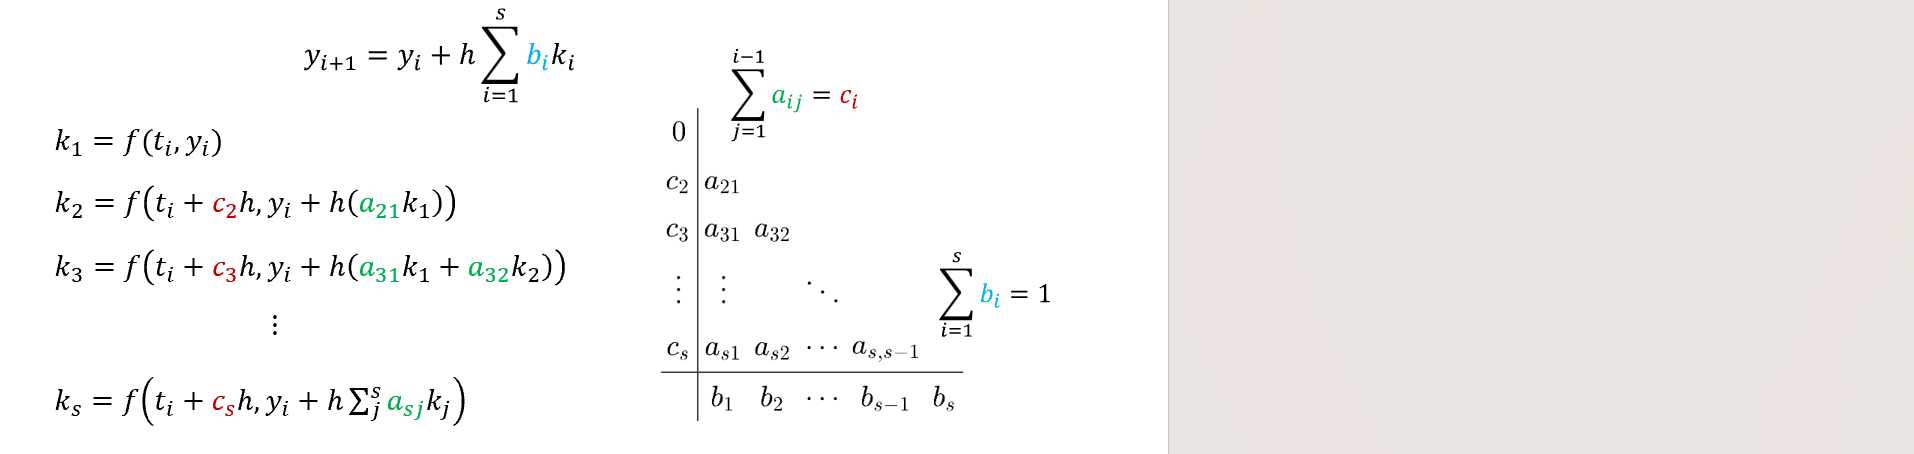

显示RK方法比较实用的是4阶精度算法，共两张类型：

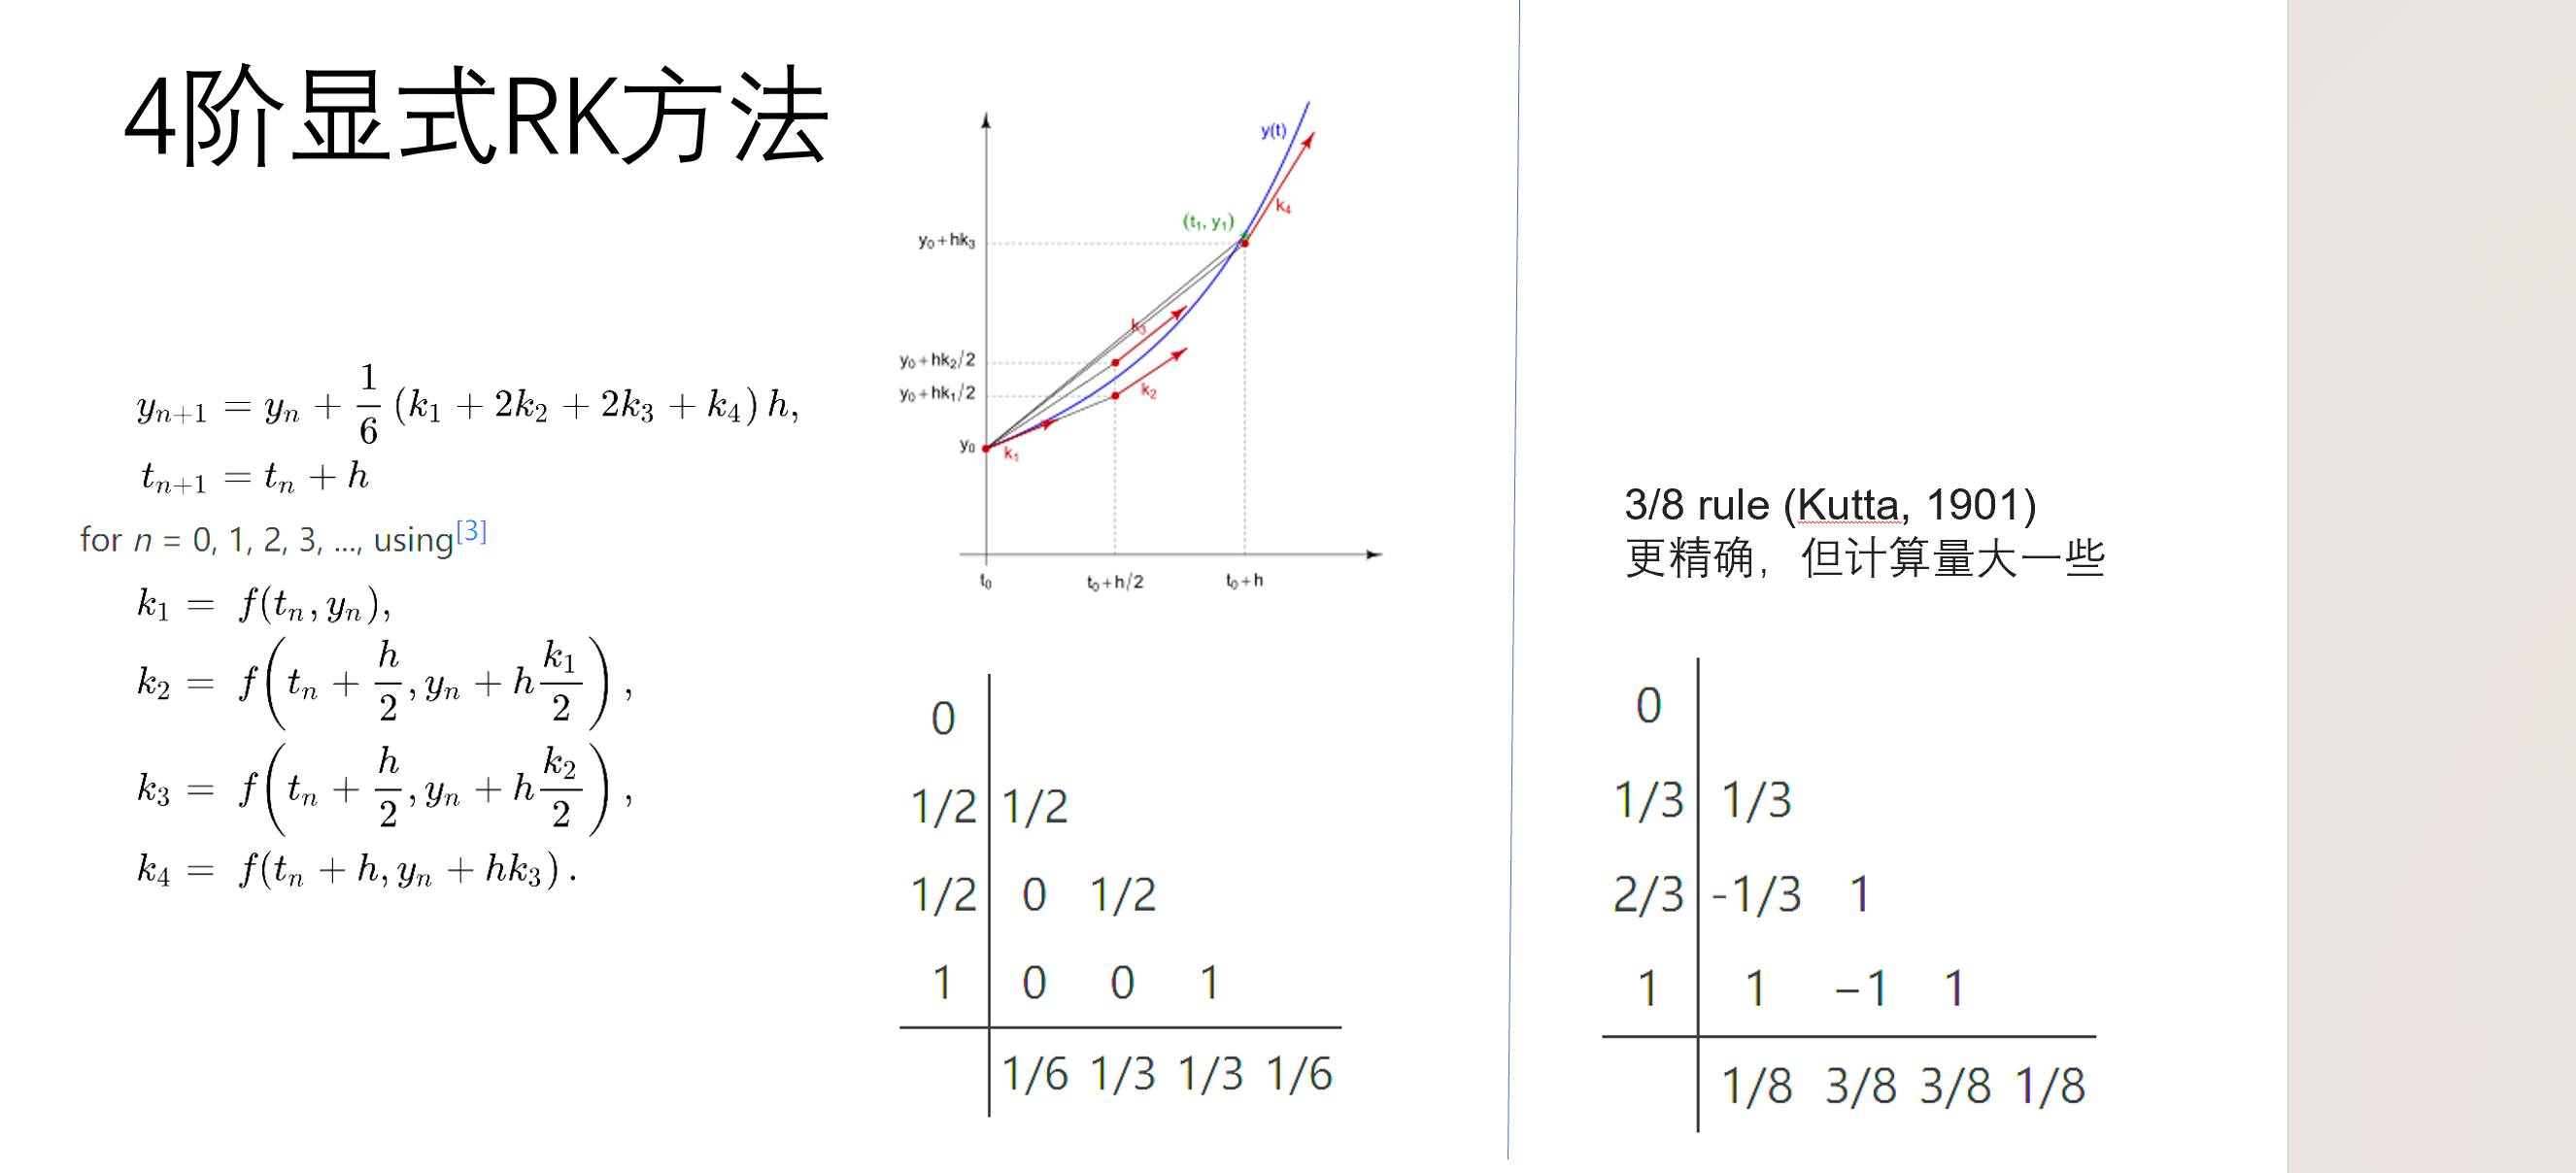

RK方法相比亚当斯法要更加精确实用，是ODE中最常用方法之一，以下为4阶显示RK方法的实现

In [14]:
def ode_rungekutta4th(func, y0, tlist, args=()):
    """
    Runge-Kutte (4th) method
    
    参数:
    ---------------
    func: myODE函数，返回 dy/dt = f(y, t)
    y0: 初始 y 值
    tlist: 自变量t数组

    可选参数：
    ------------
    args: 用于 func 的额外参数

    返回值: ylist: 求解出的tlist对应的y数组
    """
            
    t = tlist[0]
    y = y0

    ylist = [y]
        
    for tn in tlist[1:]:
        
        h = tn - t
        
        dydt = [func(y, t, *args)]
        yp = [y]
        
        for k in [0.5, 0.5, 1]:
            tk = t + k*h
            yp.append(y + k*h*dydt[-1])
            dydt.append(func(yp[-1], tk, *args))
        
        t = tn
        y = y + (dydt[0] + 2*dydt[1] + 2*dydt[2] + dydt[3])*h/6
        
        ylist.append(y)
        
    return np.array(ylist)

# 以下为更直观的RK4的实现
def ode_rungekutta4th_direct(func, y0, tlist, args=()):
    t = tlist[0]
    y = y0
    ylist = [y]
    for tn in tlist[1:]:
        h = tn - t
        k1 = func(y, t, *args)
        k2 = func(y + h*k1/2, t + h/2, *args)
        k3 = func(y + h*k2/2, t + h/2, *args)
        k4 = func(y + h*k3, t + h, *args)
        y = y + h/6 * (k1 + 2*k2 + 2*k3 + k4)
        t = tn
        ylist.append(y)
    return np.array(ylist)

我们测试其误差：

In [15]:
# 定义函数
dvdt_func = lambda v,t: -0.1*v
v_func = lambda t: np.exp(-0.1*t)

使用之前定义的函数分析局部误差，可以看到其误差依赖于$h^4$，表现很优越

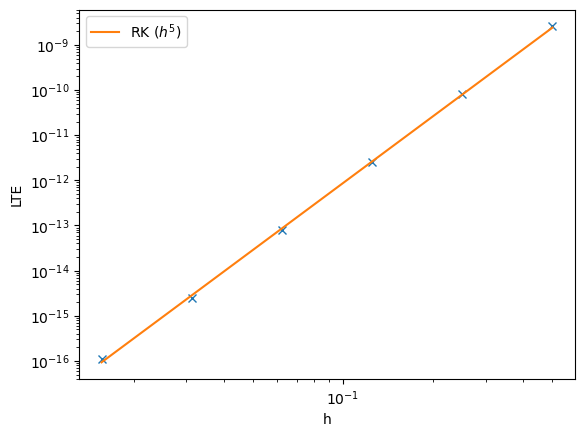

In [22]:
# 画图准备
fig, axes = plt.subplots(1,1, dpi=100)
axes = [axes] #只有一个子图时，我们手动放入一个列表里

# LTE分析，参数表： LTE_analysis(axes, odeint, dydx_func, y_func, x0, hmax, ndim=1, ndiv=5, func_args=(), ode_args=(), labels=['']):
t0 = 0
hmax = 0.5
LTE_analysis(axes, ode_rungekutta4th, dvdt_func, v_func, t0, hmax, labels=['RK'])

与显式欧拉法的误差对比

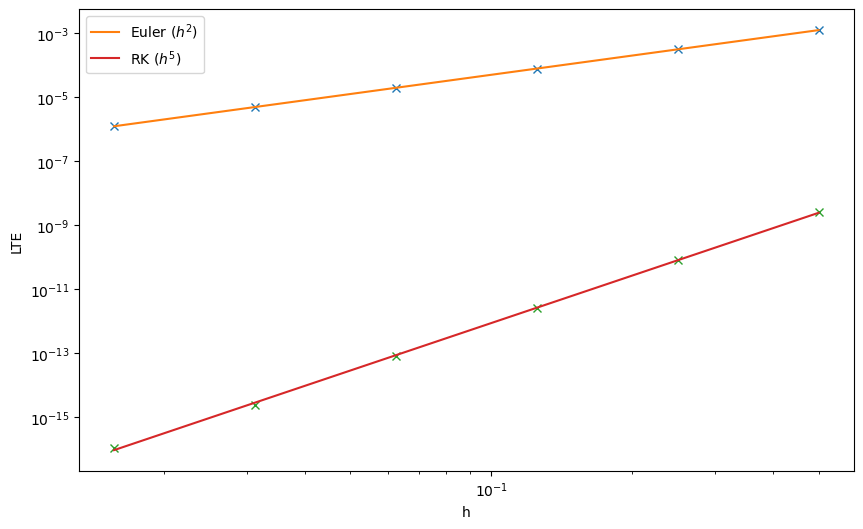

In [34]:
# 画图准备
fig, axes = plt.subplots(1,1, dpi=100,figsize = (10,6))
axes = [axes] #只有一个子图时，我们手动放入一个列表里

# LTE分析，参数表： LTE_analysis(axes, odeint, dydx_func, y_func, x0, hmax, ndim=1, ndiv=5, func_args=(), ode_args=(), labels=['']):
t0 = 0
hmax = 0.5
LTE_analysis(axes, ode_explicit_euler, dvdt_func, v_func, t0, hmax, labels=['Euler'])
LTE_analysis(axes, ode_rungekutta4th, dvdt_func, v_func, t0, hmax, labels=['RK'])

#### 此处为科研了一下如何利用`LTE_analysis`画两张图

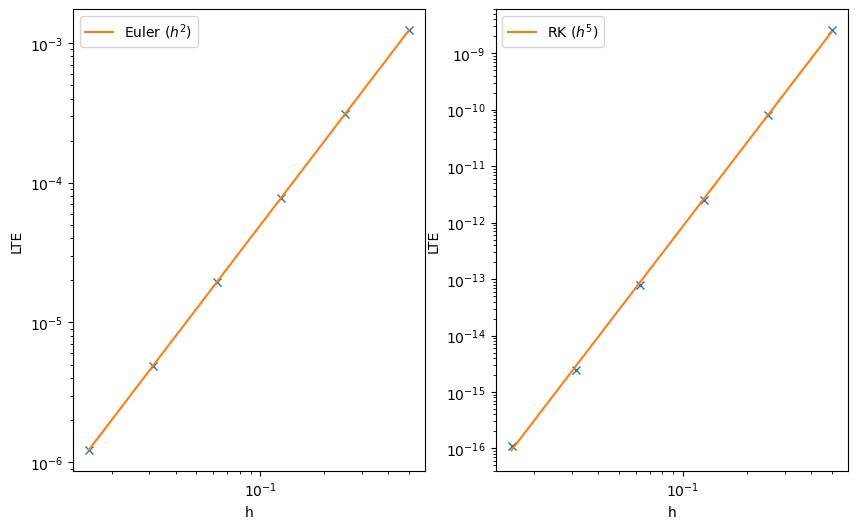

In [35]:
# 画图准备
fig, axes = plt.subplots(1,2, dpi=100,figsize = (10,6))
# axes = [axes] #只有一个子图时，我们手动放入一个列表里

# LTE分析，参数表： LTE_analysis(axes, odeint, dydx_func, y_func, x0, hmax, ndim=1, ndiv=5, func_args=(), ode_args=(), labels=['']):
t0 = 0
hmax = 0.5
LTE_analysis([axes[0]], ode_explicit_euler, dvdt_func, v_func, t0, hmax, labels=['Euler'])
LTE_analysis([axes[1]], ode_rungekutta4th, dvdt_func, v_func, t0, hmax, labels=['RK'])

继续查看累积误差，可以看到也有累积误差偏移问题，但因为精度足够高，因此偏移较为缓慢

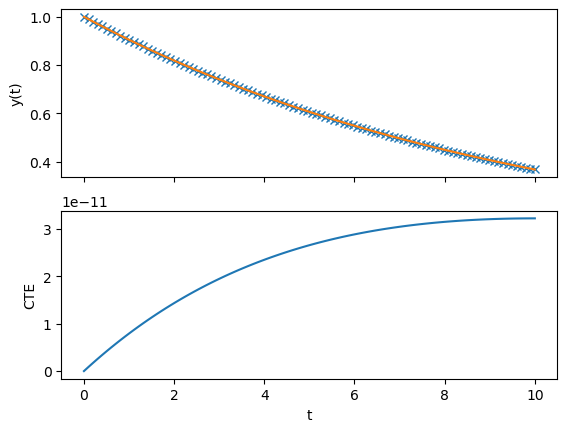

In [36]:
# 画图准备
fig, axes = plt.subplots(2,1, sharex=True, dpi=100)
axes = axes[:,None] #只有一个子图时，我们手动放入一个列表里

# LTE分析，参数表： CTE_analysis(axes, odeint, dydx_func, y_func, xlist, ndim=1, func_args=(), ode_args=(), labels=[''])
tlist = np.linspace(0,10,100)
CTE_plot(axes, ode_rungekutta4th, dvdt_func, v_func, tlist, labels=['PK'])

## Sympy 实现解析求ODE（选学）

我们也可以用SymPy实现解析求ODE，对实例1中的ODE简化后的例子：

$ \frac{d \mathbf{v}}{dt} - k v^2 = 0 $ 

以下为求解过程

In [28]:
import sympy as sy
t = sy.Symbol('t')
k = sy.Symbol('k')
v = sy.Function('v')(t) # 定义函数，自变量t
dvdt = sy.Derivative(v,t) # 定义导函数

sy.dsolve(dvdt - k*v**2) # 解析求ODE

Eq(v(t), -1/(C1 + k*t))